In [1]:
import os, csv, math, random
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms


In [21]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# ============================================================
# Experiment
# ============================================================
SEED = 0

BASE_OUT_DIR = "PRUNING/WRN28-10_CIFAR100/FOCAL_SBECE_PRUNE"
OUT_DIR = BASE_OUT_DIR

# separate folder for beta-sweep ablation
BETA_SWEEP_OUT_DIR = os.path.join(BASE_OUT_DIR, "BETA_SWEEP")
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(BETA_SWEEP_OUT_DIR, exist_ok=True)

# ============================================================
# Data
# ============================================================
BATCH_SIZE = 128
NUM_WORKERS = 4
VAL_FRACTION = 0.1

# ============================================================
# Train
# ============================================================
EPOCHS = 200
LR = 0.1
MOMENTUM = 0.9
WEIGHT_DECAY = 5e-4
LR_MILESTONES = [60, 120, 160]
LR_GAMMA = 0.2

# ============================================================
# Loss: focal + SBECE
# Recovery objective:
#   L_rec = L_focal + beta * L_SBECE
# beta = 0 corresponds to focal-only recovery
# ============================================================
FOCAL_GAMMA = 2.0
FOCAL_ALPHA = None          # keep None unless paper uses alpha

SBECE_BINS = 15
SBECE_TEMP = 0.01           # keep fixed during beta sweep

# Current/default beta used in your main experiment
DEFAULT_BETA_SBECE = 1.0
BETA_SBECE = DEFAULT_BETA_SBECE

# Already covered by focal-only fine-tuning baseline
BETA_BASELINE = 0.0

# New beta sweep values for calibration-aware recovery
BETA_GRID = [0.05, 0.1, 0.25, 0.5, 1.0, 2.0]


# Full pruning-ratio sweep for beta ablation
BETA_SWEEP_PRUNE_RATIOS = [i / 10 for i in range(1, 10)]  # 0.1 ... 0.9

# ============================================================
# Pruning / gating
# ============================================================
LAMBDA_SPARSE = 1e-4        # sparsity strength for gates
SPARSITY_RAMP_EPOCHS = 20   # ramp-in

RECOVERY_EPOCHS = 40

# Full pruning curve for main experiments
PRUNE_RATIOS = [i / 10 for i in range(0, 10)]  # 0.0 ... 0.9

ACC_DROP_TOL = 0.01         # allow at most 1% absolute acc drop vs unpruned

# ============================================================
# Metrics
# ============================================================
ECE_BINS = 15
MEAN_SWEEP_BINS = list(range(5, 31))

DEVICE: cuda


In [3]:
def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

seed_everything(SEED)

In [4]:
def get_cifar100_loaders(batch_size=128, val_fraction=0.1, num_workers=4, seed=0):
    # CIFAR-100 statistics (standard)
    mean = (0.5071, 0.4867, 0.4408)
    std  = (0.2675, 0.2565, 0.2761)

    train_tf = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    test_tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    train_full = torchvision.datasets.CIFAR100(
        root="./data", train=True, download=True, transform=train_tf
    )
    test_set = torchvision.datasets.CIFAR100(
        root="./data", train=False, download=True, transform=test_tf
    )

    n_total = len(train_full)
    n_val = int(val_fraction * n_total)
    n_train = n_total - n_val

    g = torch.Generator().manual_seed(seed)
    train_set, val_set = random_split(train_full, [n_train, n_val], generator=g)

    train_loader = DataLoader(
        train_set, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=True
    )
    val_loader = DataLoader(
        val_set, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=True
    )
    test_loader = DataLoader(
        test_set, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=True
    )

    return train_loader, val_loader, test_loader


In [5]:
train_loader, val_loader, test_loader = get_cifar100_loaders(
    batch_size=BATCH_SIZE,
    val_fraction=VAL_FRACTION,
    num_workers=NUM_WORKERS,
    seed=SEED
)


In [6]:
def get_cifar100_bn_loader(batch_size=128, num_workers=4):
    mean = (0.5071, 0.4867, 0.4408)
    std  = (0.2675, 0.2565, 0.2761)

    bn_tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    train_noaug = torchvision.datasets.CIFAR100(
        root="./data", train=True, download=False, transform=bn_tf
    )

    bn_loader = DataLoader(
        train_noaug,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )
    return bn_loader


In [7]:
bn_loader = get_cifar100_bn_loader(
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS
)

In [8]:
class ChannelGate(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.logits = nn.Parameter(torch.zeros(channels))

    def gate_values(self):
        return torch.sigmoid(self.logits)

    def forward(self, x):
        g = torch.sigmoid(self.logits)
        return x * g.view(1, -1, 1, 1)



class WideBasic(nn.Module):
    def __init__(self, in_planes, planes, dropout_rate, stride=1):
        super().__init__()
        self.bn1 = nn.BatchNorm2d(in_planes)
        self.conv1 = nn.Conv2d(in_planes, planes, 3, padding=1, bias=False)
        self.gate1 = ChannelGate(planes)

        self.dropout = nn.Dropout(p=dropout_rate) if dropout_rate > 0 else nn.Identity()

        self.bn2 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, 3, stride=stride, padding=1, bias=False)
        self.gate2 = ChannelGate(planes)

        self.shortcut = nn.Identity()
        if stride != 1 or in_planes != planes:
            self.shortcut = nn.Conv2d(in_planes, planes, 1, stride=stride, bias=False)

    def forward(self, x):
        out = self.conv1(F.relu(self.bn1(x)))
        out = self.gate1(out)
        out = self.dropout(out)

        out = self.conv2(F.relu(self.bn2(out)))
        out = self.gate2(out)

        out += self.shortcut(x)
        return out


class WideResNet(nn.Module):
    def __init__(self, depth=28, widen_factor=10, dropout_rate=0.0, num_classes=100):
        super().__init__()
        assert (depth - 4) % 6 == 0, "WRN depth must be 6n+4"
        n = (depth - 4) // 6
        k = widen_factor

        stages = [16, 16*k, 32*k, 64*k]

        self.conv1 = nn.Conv2d(3, stages[0], 3, padding=1, bias=False)
        self.layer1 = self._make_layer(stages[0], stages[1], n, dropout_rate, stride=1)
        self.layer2 = self._make_layer(stages[1], stages[2], n, dropout_rate, stride=2)
        self.layer3 = self._make_layer(stages[2], stages[3], n, dropout_rate, stride=2)
        self.bn1 = nn.BatchNorm2d(stages[3])
        self.fc = nn.Linear(stages[3], num_classes)

        self._init_weights()

    def _make_layer(self, in_planes, planes, num_blocks, dropout_rate, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        curr_in = in_planes
        for s in strides:
            layers.append(WideBasic(curr_in, planes, dropout_rate, stride=s))
            curr_in = planes
        return nn.Sequential(*layers)

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="linear")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        out = self.conv1(x)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = F.relu(self.bn1(out))
        out = F.adaptive_avg_pool2d(out, 1).view(out.size(0), -1)
        return self.fc(out)


def build_wrn28_10(num_classes=100, dropout=0.0):
    return WideResNet(depth=28, widen_factor=10, dropout_rate=dropout, num_classes=num_classes)


# sanity check
m = build_wrn28_10().to(DEVICE)
print(m(torch.randn(2, 3, 32, 32).to(DEVICE)).shape)  # [2, 100]


torch.Size([2, 100])


In [9]:
# =========================
# Channel-wise gating (BN-safe)
# =========================

class ChannelGate(nn.Module):
    """
    Channel-wise gate applied AFTER BN + ReLU.
    Safe for hardening + BN recalibration.
    """
    def __init__(self, channels):
        super().__init__()
        self.logits = nn.Parameter(torch.zeros(channels))

    def gate_values(self):
        return torch.sigmoid(self.logits)

    def forward(self, x):
        g = self.gate_values().view(1, -1, 1, 1)
        return x * g


# =========================
# Gate utilities
# =========================

@torch.no_grad()
def gather_all_gates(model: nn.Module) -> torch.Tensor:
    gates = []
    for m in model.modules():
        if isinstance(m, ChannelGate):
            gates.append(m.gate_values().detach().flatten())
    return torch.cat(gates) if len(gates) > 0 else torch.tensor([])


def gate_l1_sparsity_loss(model: nn.Module):
    """
    L1-style sparsity loss on gates.
    Use with: loss += LAMBDA_SPARSE * gate_l1_sparsity_loss(model)
    """
    vals = []
    for m in model.modules():
        if isinstance(m, ChannelGate):
            vals.append(m.gate_values())
    if len(vals) == 0:
        return torch.tensor(0.0, device=next(model.parameters()).device)
    return torch.cat(vals).mean()


# =========================
# Gate hardening (pruning)
# =========================

@torch.no_grad()
def harden_gates(model, prune_ratio):
    """
    prune_ratio: 0.1 -> prune 10%, keep 90%
    """
    for m in model.modules():
        if isinstance(m, ChannelGate):
            g = m.gate_values()
            k = int((1 - prune_ratio) * g.numel())

            if k <= 0:
                m.logits.fill_(-10.0)
                continue

            thresh = torch.topk(g, k, largest=True).values.min()
            m.logits.copy_(
                torch.where(
                    g >= thresh,
                    torch.tensor(10.0, device=g.device),
                    torch.tensor(-10.0, device=g.device),
                )
            )


In [10]:
@torch.no_grad()
def harden_binary_gates(
    model: nn.Module,
    keep_ratio: float,
    on_logit: float = 10.0,
    off_logit: float = -10.0,
):
    """
    Per-layer hardening for ChannelGate.
    Keeps top keep_ratio channels per gate (per gate module).
    """
    for m in model.modules():
        if isinstance(m, ChannelGate):
            g = m.gate_values().detach()
            C = g.numel()
            k = max(1, int(round(keep_ratio * C)))

            idx = torch.topk(g, k, largest=True).indices
            keep = torch.zeros_like(g, dtype=torch.bool)
            keep[idx] = True

            m.logits.data[keep]  = on_logit
            m.logits.data[~keep] = off_logit


def set_gate_trainable(model: nn.Module, trainable: bool):
    for m in model.modules():
        if isinstance(m, ChannelGate):
            m.logits.requires_grad_(trainable)


@torch.no_grad()
def gate_stats(model: nn.Module):
    """Returns (gate_mean, density@0.5) across all ChannelGate modules."""
    gs = []
    for m in model.modules():
        if isinstance(m, ChannelGate):
            gs.append(m.gate_values().detach().flatten())
    if len(gs) == 0:
        return 0.0, 0.0
    g = torch.cat(gs, 0)
    mean = float(g.mean().item())
    dens = float((g > 0.5).float().mean().item())
    return mean, dens


# ============================================================
# Robust checkpoint loader
# ============================================================

def load_checkpoint_strict(model, ckpt_path, device):
    print(f"Loading checkpoint from: {ckpt_path}")
    ckpt = torch.load(ckpt_path, map_location=device)

    if isinstance(ckpt, dict):
        if "state_dict" in ckpt:
            state_dict = ckpt["state_dict"]
        elif "model_state_dict" in ckpt:
            state_dict = ckpt["model_state_dict"]
        elif "model" in ckpt:
            state_dict = ckpt["model"]
        else:
            state_dict = ckpt
    else:
        state_dict = ckpt

    # remove DataParallel prefix if present
    new_state_dict = {}
    for k, v in state_dict.items():
        if k.startswith("module."):
            k = k.replace("module.", "", 1)
        new_state_dict[k] = v

    missing, unexpected = model.load_state_dict(new_state_dict, strict=False)

    print("Checkpoint loaded.")
    print("Missing keys:", len(missing))
    print("Unexpected keys:", len(unexpected))

    if len(missing) > 0:
        print("First missing keys:", missing[:10])
    if len(unexpected) > 0:
        print("First unexpected keys:", unexpected[:10])

    return model

In [11]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None, reduction="mean"):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.reduction = reduction

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, reduction="none")
        pt = torch.exp(-ce)  # pt = softmax prob of true class
        loss = (1 - pt) ** self.gamma * ce

        if self.alpha is not None:
            # alpha can be scalar or per-class tensor
            if isinstance(self.alpha, (float, int)):
                loss = self.alpha * loss
            else:
                a = self.alpha.to(logits.device)
                loss = a[targets] * loss

        if self.reduction == "mean":
            return loss.mean()
        if self.reduction == "sum":
            return loss.sum()
        return loss


In [12]:
@torch.no_grad()
def reset_bn_running_stats(model: nn.Module):
    for m in model.modules():
        if isinstance(m, nn.BatchNorm2d):
            m.running_mean.zero_()
            m.running_var.fill_(1)

@torch.no_grad()
def update_bn_stats(model: nn.Module, loader, device, num_batches=100):
    model.train()
    n = 0
    for x, _ in loader:
        x = x.to(device, non_blocking=True)
        _ = model(x)
        n += 1
        if n >= num_batches:
            break

In [23]:
# ============================================================
# HPO BETA CIFAR-100: Ours - beta sweep for calibration-aware FT
# Calibration-aware gates + focal + beta*SBECE recovery FT
# ============================================================

import os, csv, time
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd


# ============================================================
# Paths / HPO setup
# ============================================================

ABLATION_CKPT = (
    "PRUNING/WRN28-10_CIFAR100/FOCAL_SBECE_PRUNE/"
    "wrn28_10_cifar100_unpruned.pth"
)

HPO_BETA_OUT_DIR = (
    "PRUNING/WRN28-10_CIFAR100/FOCAL_SBECE_PRUNE/"
    "HPO_beta"
)

os.makedirs(HPO_BETA_OUT_DIR, exist_ok=True)


# Full pruning sweep for beta HPO
BETA_SWEEP_PRUNE_RATIOS = [i / 10 for i in range(1, 10)]  # 0.1 ... 0.9

# beta=0 is already covered by focal-only FT baseline
BETA_GRID = [0.05, 0.1, 0.25, 0.5, 1.0, 2.0]


# ============================================================
# Focal classification loss
# ============================================================

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None, reduction="mean"):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.reduction = reduction

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, reduction="none")
        pt = torch.exp(-ce)
        loss = (1 - pt) ** self.gamma * ce

        if self.alpha is not None:
            if isinstance(self.alpha, (float, int)):
                loss = self.alpha * loss
            else:
                a = self.alpha.to(logits.device)
                loss = a[targets] * loss

        if self.reduction == "mean":
            return loss.mean()
        if self.reduction == "sum":
            return loss.sum()
        return loss


# ============================================================
# Differentiable soft-binning ECE loss
# ============================================================

class SoftBinningECELoss(nn.Module):
    """
    Soft-binning ECE-style calibration loss.

    Uses soft assignment of confidence values to bin centers.
    Prediction correctness is treated as a fixed target signal,
    while confidence remains differentiable through logits.
    """
    def __init__(self, n_bins=15, temp=0.01, eps=1e-8):
        super().__init__()
        self.n_bins = n_bins
        self.temp = temp
        self.eps = eps

        centers = torch.linspace(
            1.0 / (2 * n_bins),
            1.0 - 1.0 / (2 * n_bins),
            n_bins,
        )
        self.register_buffer("centers", centers)

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)
        confs, preds = probs.max(dim=1)
        correct = preds.eq(targets).float()

        # Soft assignment to confidence-bin centers
        # shape: [batch, n_bins]
        dist = torch.abs(confs.unsqueeze(1) - self.centers.unsqueeze(0))
        weights = F.softmax(-dist / self.temp, dim=1)

        bin_mass = weights.sum(dim=0) + self.eps
        bin_prob = bin_mass / (weights.size(0) + self.eps)

        bin_conf = (weights * confs.unsqueeze(1)).sum(dim=0) / bin_mass
        bin_acc = (weights * correct.unsqueeze(1)).sum(dim=0) / bin_mass

        # Smooth absolute difference
        diff = torch.sqrt((bin_conf - bin_acc) ** 2 + self.eps)

        sbece = (bin_prob * diff).sum()
        return sbece


# ============================================================
# Robust checkpoint loader
# ============================================================

def load_checkpoint_strict(model, ckpt_path, device):
    print(f"Loading checkpoint from: {ckpt_path}")
    ckpt = torch.load(ckpt_path, map_location=device)

    if isinstance(ckpt, dict) and "state_dict" in ckpt:
        state_dict = ckpt["state_dict"]
    elif isinstance(ckpt, dict) and "model_state_dict" in ckpt:
        state_dict = ckpt["model_state_dict"]
    elif isinstance(ckpt, dict) and "model" in ckpt:
        state_dict = ckpt["model"]
    else:
        state_dict = ckpt

    state_dict = {
        k.replace("module.", "", 1) if k.startswith("module.") else k: v
        for k, v in state_dict.items()
    }

    missing, unexpected = model.load_state_dict(state_dict, strict=False)
    print("Checkpoint loaded.")
    print("Missing keys:", len(missing))
    print("Unexpected keys:", len(unexpected))

    if len(missing) > 0:
        print("First missing keys:", missing[:10])
    if len(unexpected) > 0:
        print("First unexpected keys:", unexpected[:10])

    return model.to(device)


# ============================================================
# One epoch: focal + beta*SBECE fine-tuning
# ============================================================

def train_one_epoch_focal_sbece(
    model,
    loader,
    optimizer,
    device,
    focal_loss_fn,
    sbece_loss_fn,
    beta_sbece,
):
    model.train()

    total = 0
    sum_loss = 0.0
    sum_focal = 0.0
    sum_sbece = 0.0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)

        focal = focal_loss_fn(logits, y)
        sbece = sbece_loss_fn(logits, y)

        loss = focal + beta_sbece * sbece

        loss.backward()
        optimizer.step()

        bs = y.size(0)
        total += bs
        sum_loss += float(loss.item()) * bs
        sum_focal += float(focal.item()) * bs
        sum_sbece += float(sbece.item()) * bs

    return {
        "loss": sum_loss / total,
        "focal": sum_focal / total,
        "sbece": sum_sbece / total,
        "beta_sbece": beta_sbece,
    }


# ============================================================
# Recovery fine-tuning: focal + beta*SBECE
# ============================================================

def recovery_finetune_focal_sbece_earlystop(
    model,
    train_loader,
    val_loader,
    test_loader,
    device,
    lr,
    weight_decay,
    focal_loss_fn,
    sbece_loss_fn,
    beta_sbece,
    out_dir,
    tag,
    max_epochs=40,
    eval_every=1,
    patience=10,
    min_delta=1e-4,
    no_stop_before_ep=10,
    print_every=1,
):
    os.makedirs(out_dir, exist_ok=True)

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=lr,
        momentum=MOMENTUM,
        weight_decay=weight_decay,
        nesterov=True,
    )

    scheduler = torch.optim.lr_scheduler.MultiStepLR(
        optimizer,
        milestones=[80, 120],
        gamma=0.1,
    )

    best_val_acc = -1.0
    best_state = None
    bad_steps = 0
    rows = []
    t0 = time.time()

    for ep in range(1, max_epochs + 1):
        tr = train_one_epoch_focal_sbece(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            device=device,
            focal_loss_fn=focal_loss_fn,
            sbece_loss_fn=sbece_loss_fn,
            beta_sbece=beta_sbece,
        )

        scheduler.step()

        row = {
            "epoch": ep,
            "lr": float(optimizer.param_groups[0]["lr"]),
            "train_loss": float(tr["loss"]),
            "train_focal": float(tr["focal"]),
            "train_sbece": float(tr["sbece"]),
            "beta_sbece": float(beta_sbece),
            "finetune_loss": "focal_plus_sbece",
        }

        do_eval = (ep % eval_every == 0) or (ep == 1) or (ep == max_epochs)

        if do_eval:
            model.eval()
            m = evaluate_all_metrics(model, val_loader, test_loader, device)

            row.update({
                "val_acc": float(m["acc"]),
                "val_nll": float(m["nll"]),
                "val_ece": float(m["ece"]),
                "val_ts_ece": float(m["ts_ece"]),
                "val_ks": float(m.get("ks", float("nan"))),
                "val_mean_sweep_ce": float(m.get("mean_sweep_ce", float("nan"))),
            })

            improved = row["val_acc"] > (best_val_acc + min_delta)

            if improved:
                best_val_acc = row["val_acc"]
                best_state = {
                    k: v.detach().cpu()
                    for k, v in model.state_dict().items()
                }
                bad_steps = 0
            else:
                if ep >= no_stop_before_ep:
                    bad_steps += 1

            if (ep == 1) or (ep % print_every == 0) or improved:
                print(
                    f"   [{tag}] ep {ep:03d}/{max_epochs} | "
                    f"loss={row['train_loss']:.4f} "
                    f"focal={row['train_focal']:.4f} "
                    f"sbece={row['train_sbece']:.4f} "
                    f"beta={beta_sbece:.3f} | "
                    f"val_acc={row['val_acc']:.4f} "
                    f"val_ece={row['val_ece']:.4f} "
                    f"best_acc={best_val_acc:.4f} "
                    f"bad={bad_steps}/{patience}"
                )

            if (ep >= no_stop_before_ep) and (bad_steps >= patience):
                print(f"   [{tag}] Early stopping at epoch {ep}")
                break

        rows.append(row)

    if best_state is not None:
        model.load_state_dict(best_state, strict=True)

    model.eval()
    final_metrics = evaluate_all_metrics(model, val_loader, test_loader, device)

    beta_tag = f"beta{str(beta_sbece).replace('.', 'p')}"
    curves_path = os.path.join(out_dir, f"curves_{tag}_{beta_tag}.csv")
    best_path = os.path.join(out_dir, f"best_{tag}_{beta_tag}.pth")

    pd.DataFrame(rows).to_csv(curves_path, index=False)

    torch.save(
        {
            "state_dict": model.state_dict(),
            "final_metrics": final_metrics,
            "tag": tag,
            "dataset": "cifar100",
            "ablation": "hpo_beta",
            "finetune_loss": "focal_plus_sbece",
            "beta_sbece": float(beta_sbece),
        },
        best_path,
    )

    print(f"   [{tag}] Saved curves -> {curves_path}")
    print(f"   [{tag}] Saved best   -> {best_path}")
    print(f"   [{tag}] Time: {(time.time() - t0) / 60:.1f} min")

    return final_metrics, curves_path, best_path


# ============================================================
# Main CIFAR-100 beta HPO sweep
# ============================================================

def run_hpo_beta_from_checkpoint_cifar100(
    ckpt_path,
    out_dir,
    prune_ratios,
    beta_grid,
    max_recovery_epochs=40,
    eval_every=1,
    patience=10,
    no_stop_before_ep=10,
    bn_num_batches=100,
):
    os.makedirs(out_dir, exist_ok=True)

    train_loader, val_loader, test_loader = get_cifar100_loaders(
        batch_size=BATCH_SIZE,
        val_fraction=VAL_FRACTION,
        num_workers=NUM_WORKERS,
        seed=SEED,
    )

    bn_loader = get_cifar100_bn_loader(
        batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS,
    )

    base_model = build_wrn28_10(num_classes=100, dropout=0.0).to(DEVICE)
    base_model = load_checkpoint_strict(base_model, ckpt_path, DEVICE)

    base_metrics = evaluate_all_metrics(base_model, val_loader, test_loader, DEVICE)
    gm, gd = gate_stats(base_model)

    print("BASELINE:", base_metrics, f"| gate_mean={gm:.3f} density@0.5={gd:.3f}")

    base_state = {
        k: v.detach().cpu()
        for k, v in base_model.state_dict().items()
    }

    focal_fn = FocalLoss(
        gamma=FOCAL_GAMMA,
        alpha=FOCAL_ALPHA,
    ).to(DEVICE)

    sbece_fn = SoftBinningECELoss(
        n_bins=SBECE_BINS,
        temp=SBECE_TEMP,
    ).to(DEVICE)

    csv_path = os.path.join(out_dir, "metrics_hpo_beta_cifar100.csv")

    with open(csv_path, "w", newline="") as f:
        writer = csv.writer(f)

        writer.writerow([
            "ablation",
            "dataset",
            "gate_selection",
            "finetune_loss",
            "beta_sbece",
            "prune_ratio",
            "keep_ratio",

            # baseline before pruning
            "base_acc",
            "base_nll",
            "base_ece",
            "base_ts_ece",
            "base_ks",
            "base_mean_sweep_ce",

            # after pruning/hardening + BN recalibration, before FT
            "post_harden_acc",
            "post_harden_nll",
            "post_harden_ece",
            "post_harden_ts_ece",
            "post_harden_ks",
            "post_harden_mean_sweep_ce",

            # after recovery FT
            "final_acc",
            "final_nll",
            "final_ece",
            "final_ts_ece",
            "final_ks",
            "final_mean_sweep_ce",

            "acc_drop_from_base",
            "accepted_acc_drop<=tol",
            "best_ckpt_path",
            "curves_csv_path",
        ])

        for beta_sbece in beta_grid:
            beta_tag = f"beta{str(beta_sbece).replace('.', 'p')}"
            beta_out_dir = os.path.join(out_dir, beta_tag)
            os.makedirs(beta_out_dir, exist_ok=True)

            print(f"\nSaving beta={beta_sbece} results to:")
            print(os.path.abspath(beta_out_dir))
 
            for prune_ratio in prune_ratios:
                keep_ratio = 1.0 - prune_ratio

                tag = (
                    f"cifar100_prune{int(prune_ratio * 100):02d}"
                    f"_keep{int(keep_ratio * 100):02d}"
                    f"_{beta_tag}"
                )

                print("\n" + "=" * 80)
                print(
                    f"[{tag}] Calibration-aware gates + "
                    f"focal + beta*SBECE recovery"
                )
                print("=" * 80)

                model_p = build_wrn28_10(num_classes=100, dropout=0.0).to(DEVICE)
                model_p.load_state_dict(base_state, strict=True)

                # -------------------------------
                # 1. Prune / harden gates
                # -------------------------------
                harden_binary_gates(model_p, keep_ratio=keep_ratio)
                set_gate_trainable(model_p, False)

                # -------------------------------
                # 2. BN recalibration after pruning
                # -------------------------------
                reset_bn_running_stats(model_p)
                update_bn_stats(
                    model_p,
                    bn_loader,
                    DEVICE,
                    num_batches=bn_num_batches,
                )

                # -------------------------------
                # 3. Evaluate immediately after pruning
                #    BEFORE recovery fine-tuning
                # -------------------------------
                model_p.eval()
                mh = evaluate_all_metrics(
                    model_p,
                    val_loader,
                    test_loader,
                    DEVICE,
                )

                print(
                    f"-> Post-harden/pre-FT eval: "
                    f"acc={mh['acc']:.4f}, "
                    f"nll={mh['nll']:.4f}, "
                    f"ece={mh['ece']:.4f}, "
                    f"ts_ece={mh['ts_ece']:.4f}, "
                    f"ks={mh.get('ks', float('nan')):.4f}, "
                    f"mean_sweep_ce={mh.get('mean_sweep_ce', float('nan')):.4f}"
                )

                # -------------------------------
                # 4. Recovery fine-tuning
                # -------------------------------
                m, curves_csv, best_ckpt = recovery_finetune_focal_sbece_earlystop(
                    model=model_p,
                    train_loader=train_loader,
                    val_loader=val_loader,
                    test_loader=test_loader,
                    device=DEVICE,
                    lr=LR * 0.1,
                    weight_decay=WEIGHT_DECAY,
                    focal_loss_fn=focal_fn,
                    sbece_loss_fn=sbece_fn,
                    beta_sbece=beta_sbece,
                    out_dir=beta_out_dir,   # important
                    tag=tag,
                    max_epochs=max_recovery_epochs,
                    eval_every=eval_every,
                    patience=patience,
                    no_stop_before_ep=no_stop_before_ep,
                    print_every=1,
                )

                acc_drop = base_metrics["acc"] - m["acc"]
                accepted = acc_drop <= ACC_DROP_TOL

                print(
                    f"-> Final: "
                    f"acc={m['acc']:.4f}, "
                    f"nll={m['nll']:.4f}, "
                    f"ece={m['ece']:.4f}, "
                    f"ts_ece={m['ts_ece']:.4f}, "
                    f"ks={m.get('ks', float('nan')):.4f}, "
                    f"mean_sweep_ce={m.get('mean_sweep_ce', float('nan')):.4f} | "
                    f"acc_drop={acc_drop:.4f} | accepted={accepted}"
                )

                writer.writerow([
                    "hpo_beta",
                    "cifar100",
                    "calibration_aware",
                    "focal_plus_sbece",
                    beta_sbece,
                    prune_ratio,
                    keep_ratio,

                    base_metrics["acc"],
                    base_metrics["nll"],
                    base_metrics["ece"],
                    base_metrics["ts_ece"],
                    base_metrics.get("ks", float("nan")),
                    base_metrics.get("mean_sweep_ce", float("nan")),

                    mh["acc"],
                    mh["nll"],
                    mh["ece"],
                    mh["ts_ece"],
                    mh.get("ks", float("nan")),
                    mh.get("mean_sweep_ce", float("nan")),

                    m["acc"],
                    m["nll"],
                    m["ece"],
                    m["ts_ece"],
                    m.get("ks", float("nan")),
                    m.get("mean_sweep_ce", float("nan")),

                    acc_drop,
                    accepted,
                    best_ckpt,
                    curves_csv,
                ])

                f.flush()

    print("DONE ->", csv_path)
    return csv_path

In [24]:
@torch.no_grad()
def collect_logits_and_labels(model, loader, device):
    model.eval()
    logits_list, labels_list = [], []
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        logits = model(x)
        logits_list.append(logits.detach().cpu())
        labels_list.append(y.detach().cpu())
    return torch.cat(logits_list, 0), torch.cat(labels_list, 0)

@torch.no_grad()
def acc_from_logits(logits, labels):
    return float((logits.argmax(1) == labels).float().mean().item())

@torch.no_grad()
def nll_from_logits(logits, labels):
    return float(F.cross_entropy(logits, labels, reduction="mean").item())

@torch.no_grad()
def ece_from_logits(logits, labels, n_bins=15, temperature=1.0):
    probs = F.softmax(logits / temperature, dim=1)
    conf, pred = probs.max(1)
    acc = pred.eq(labels).float()

    edges = torch.linspace(0, 1, n_bins + 1, device=logits.device)
    ece = torch.zeros(1, device=logits.device)

    for b in range(n_bins):
        lo, hi = edges[b], edges[b+1]
        inb = (conf > lo) & (conf <= hi)
        p = inb.float().mean()
        if p.item() > 0:
            ece += p * torch.abs(conf[inb].mean() - acc[inb].mean())
    return float(ece.item())

@torch.no_grad()
def ks_calibration_error(logits, labels, temperature=1.0):
    probs = F.softmax(logits / temperature, dim=1)
    conf, pred = probs.max(1)
    correct = pred.eq(labels).float()

    conf_sorted, idx = torch.sort(conf)
    corr_sorted = correct[idx]
    denom = torch.arange(1, len(conf_sorted)+1, device=logits.device).float()
    cum_acc = torch.cumsum(corr_sorted, 0) / denom
    cum_conf = torch.cumsum(conf_sorted, 0) / denom
    return float(torch.max(torch.abs(cum_acc - cum_conf)).item())

@torch.no_grad()
def mean_sweep_ce(logits, labels, bin_list, temperature=1.0):
    vals = [ece_from_logits(logits, labels, n_bins=b, temperature=temperature) for b in bin_list]
    return float(np.mean(vals))

def fit_temperature(logits_val_cpu, labels_val_cpu, device, max_iter=50):
    logits = logits_val_cpu.to(device)
    labels = labels_val_cpu.to(device)

    logT = torch.zeros(1, device=device, requires_grad=True)
    opt = torch.optim.LBFGS([logT], lr=0.5, max_iter=max_iter, line_search_fn="strong_wolfe")

    def closure():
        opt.zero_grad()
        T = torch.exp(logT)
        loss = F.cross_entropy(logits / T, labels)
        loss.backward()
        return loss

    opt.step(closure)
    T = float(torch.exp(logT).detach().cpu().item())
    return max(1e-3, min(T, 100.0))

@torch.no_grad()
def evaluate_all_metrics(model, val_loader, test_loader, device):
    logits_val, labels_val = collect_logits_and_labels(model, val_loader, device)
    logits_test, labels_test = collect_logits_and_labels(model, test_loader, device)

    logits_test = logits_test.to(device)
    labels_test = labels_test.to(device)

    # base
    acc = acc_from_logits(logits_test, labels_test)
    nll = nll_from_logits(logits_test, labels_test)
    ece = ece_from_logits(logits_test, labels_test, n_bins=ECE_BINS)
    ks  = ks_calibration_error(logits_test, labels_test)
    ms  = mean_sweep_ce(logits_test, labels_test, MEAN_SWEEP_BINS)

    # TS
    T = fit_temperature(logits_val, labels_val, device=device)
    ts_nll = nll_from_logits(logits_test / T, labels_test)
    ts_ece = ece_from_logits(logits_test, labels_test, n_bins=ECE_BINS, temperature=T)
    ts_ks  = ks_calibration_error(logits_test, labels_test, temperature=T)
    ts_ms  = mean_sweep_ce(logits_test, labels_test, MEAN_SWEEP_BINS, temperature=T)

    return {
        "acc": acc, "nll": nll, "ece": ece, "ts_ece": ts_ece,
        "ks": ks, "ts_ks": ts_ks,
        "mean_sweep_ce": ms, "ts_mean_sweep_ce": ts_ms,
        "ts_temperature": T,
        "ts_nll": ts_nll,
    }


In [25]:
# ============================================================
# Run HPO beta sweep
# ============================================================

csv_path = run_hpo_beta_from_checkpoint_cifar100(
    ckpt_path=ABLATION_CKPT,
    out_dir=HPO_BETA_OUT_DIR,
    prune_ratios=BETA_SWEEP_PRUNE_RATIOS,
    beta_grid=BETA_GRID,
    max_recovery_epochs=RECOVERY_EPOCHS,
    eval_every=1,
    patience=10,
    no_stop_before_ep=10,
    bn_num_batches=100,
)

print("HPO beta CSV saved at:", csv_path)

Loading checkpoint from: PRUNING/WRN28-10_CIFAR100/FOCAL_SBECE_PRUNE/wrn28_10_cifar100_unpruned.pth
Checkpoint loaded.
Missing keys: 0
Unexpected keys: 0
BASELINE: {'acc': 0.7967999577522278, 'nll': 0.7852343916893005, 'ece': 0.06257856637239456, 'ts_ece': 0.03717036545276642, 'ks': 0.11729384958744049, 'ts_ks': 0.10168549418449402, 'mean_sweep_ce': 0.06220880881525003, 'ts_mean_sweep_ce': 0.0371604785323143, 'ts_temperature': 1.1497009992599487, 'ts_nll': 0.7587488293647766} | gate_mean=0.501 density@0.5=0.577

Saving beta=0.05 results to:
/home/ec2-user/PRUNING/WRN28-10_CIFAR100/FOCAL_SBECE_PRUNE/HPO_beta/beta0p05

[cifar100_prune10_keep90_beta0p05] Calibration-aware gates + focal + beta*SBECE recovery
-> Post-harden/pre-FT eval: acc=0.7180, nll=1.0857, ece=0.0617, ts_ece=0.0538, ks=0.1371, mean_sweep_ce=0.0620
   [cifar100_prune10_keep90_beta0p05] ep 001/40 | loss=0.0094 focal=0.0075 sbece=0.0386 beta=0.050 | val_acc=0.7767 val_ece=0.0519 best_acc=0.7767 bad=0/10
   [cifar100_prune1

KeyboardInterrupt: 

In [26]:
import os
import pandas as pd
import numpy as np

# ============================================================
# Paths
# ============================================================

HPO_CSV = (
    "PRUNING/WRN28-10_CIFAR100/FOCAL_SBECE_PRUNE/"
    "HPO_beta/metrics_hpo_beta_cifar100.csv"
)

BETA0_CSV = (
    "PRUNING/WRN28-10_CIFAR100/FOCAL_SBECE_PRUNE/"
    "ABLATION_OURS_MINUS_CALIB_FT/metrics_ours_minus_calib_ft_cifar100.csv"
)

OUT_DIR = (
    "PRUNING/WRN28-10_CIFAR100/FOCAL_SBECE_PRUNE/"
    "HPO_beta"
)

os.makedirs(OUT_DIR, exist_ok=True)

CLEAN_CSV = os.path.join(OUT_DIR, "clean_hpo_beta_metrics.csv")
SELECTED_CSV = os.path.join(OUT_DIR, "selected_beta_per_pruning_ratio.csv")


# ============================================================
# Explicit HPO grid used for official selection
# beta=0 comes from focal-only FT
# beta=2.0 is excluded because it was stopped / incomplete
# ============================================================

OFFICIAL_BETA_GRID = [0.0, 0.05, 0.10, 0.25, 0.50, 1.00]
OFFICIAL_PRUNE_RATIOS = [i / 10 for i in range(1, 10)]  # 0.1 ... 0.9


# ============================================================
# 1. Load beta sweep results: beta > 0
# ============================================================

df_hpo = pd.read_csv(HPO_CSV)

hpo_clean = df_hpo[[
    "prune_ratio",
    "beta_sbece",
    "final_acc",
    "final_nll",
    "final_ece",
]].copy()

hpo_clean = hpo_clean.rename(columns={
    "beta_sbece": "beta",
    "final_acc": "acc",
    "final_nll": "nll",
    "final_ece": "ece",
})

hpo_clean["source"] = "beta_sweep"

# Keep only official non-zero beta values
hpo_clean = hpo_clean[
    hpo_clean["beta"].isin([b for b in OFFICIAL_BETA_GRID if b > 0])
].copy()


# ============================================================
# 2. Load focal-only result and add as beta = 0
# ============================================================

df_beta0 = pd.read_csv(BETA0_CSV)

beta0_clean = df_beta0[[
    "prune_ratio",
    "final_acc",
    "final_nll",
    "final_ece",
]].copy()

beta0_clean = beta0_clean.rename(columns={
    "final_acc": "acc",
    "final_nll": "nll",
    "final_ece": "ece",
})

beta0_clean["beta"] = 0.0
beta0_clean["source"] = "focal_only"


# ============================================================
# 3. Combine and clean
# ============================================================

clean_df = pd.concat([beta0_clean, hpo_clean], ignore_index=True)

clean_df = clean_df[[
    "prune_ratio",
    "beta",
    "acc",
    "nll",
    "ece",
    "source",
]]

# Keep only official pruning ratios and beta values
clean_df = clean_df[
    clean_df["prune_ratio"].isin(OFFICIAL_PRUNE_RATIOS)
    & clean_df["beta"].isin(OFFICIAL_BETA_GRID)
].copy()

# Remove accidental duplicates, keeping the last recorded result
clean_df = clean_df.sort_values(["prune_ratio", "beta"]).drop_duplicates(
    subset=["prune_ratio", "beta"],
    keep="last"
)

clean_df = clean_df.sort_values(["prune_ratio", "beta"]).reset_index(drop=True)

clean_df.to_csv(CLEAN_CSV, index=False)

print("Saved clean HPO CSV:", CLEAN_CSV)
display(clean_df)


# ============================================================
# 4. Check missing beta/pruning combinations
# ============================================================

expected = pd.MultiIndex.from_product(
    [OFFICIAL_PRUNE_RATIOS, OFFICIAL_BETA_GRID],
    names=["prune_ratio", "beta"]
).to_frame(index=False)

available = clean_df[["prune_ratio", "beta"]].copy()

missing = expected.merge(
    available,
    on=["prune_ratio", "beta"],
    how="left",
    indicator=True
)

missing = missing[missing["_merge"] == "left_only"].drop(columns=["_merge"])

if len(missing) > 0:
    print("\nWARNING: Missing official HPO combinations:")
    display(missing)
else:
    print("\nAll official HPO combinations are available.")

Saved clean HPO CSV: PRUNING/WRN28-10_CIFAR100/FOCAL_SBECE_PRUNE/HPO_beta/clean_hpo_beta_metrics.csv


,prune_ratio,beta,acc,nll,ece,source
0,0.1,0.00,0.7961,0.778426,0.042643,focal_only
1,0.1,0.05,0.7976,0.780311,0.032303,beta_sweep
2,0.1,0.10,0.7968,0.759974,0.023630,beta_sweep
3,0.1,0.25,0.7686,0.874188,0.037309,beta_sweep
4,0.1,0.50,0.7041,1.066504,0.056548,beta_sweep
5,0.1,1.00,0.6019,1.420264,0.055281,beta_sweep
6,0.2,0.00,0.7906,0.792007,0.029090,focal_only
7,0.2,0.05,0.7905,0.792110,0.027883,beta_sweep
8,0.2,0.10,0.7890,0.789412,0.024534,beta_sweep
9,0.2,0.25,0.7522,0.926333,0.043334,beta_sweep



All official HPO combinations are available.


In [27]:
# ============================================================
# 4. Select best beta per pruning ratio
# Rule:
# - For each pruning ratio, find max validation accuracy.
# - Keep betas within 0.5 percentage point of that max accuracy.
# - Among them, choose lowest ECE.
# ============================================================

df = pd.read_csv(CLEAN_CSV)

ACC_TOL = 0.005   # 0.5 percentage point because acc is in 0-1 scale

df["max_acc_at_prune"] = df.groupby("prune_ratio")["acc"].transform("max")
df["acc_gap_from_best"] = df["max_acc_at_prune"] - df["acc"]

df["accuracy_feasible"] = df["acc_gap_from_best"] <= ACC_TOL

feasible_df = df[df["accuracy_feasible"]].copy()

selected = (
    feasible_df
    .sort_values(
        ["prune_ratio", "ece", "acc", "beta"],
        ascending=[True, True, False, True]
    )
    .groupby("prune_ratio")
    .head(1)
    .reset_index(drop=True)
)

selected.to_csv(SELECTED_CSV, index=False)

print("Saved selected beta CSV:", SELECTED_CSV)
display(selected)

Saved selected beta CSV: PRUNING/WRN28-10_CIFAR100/FOCAL_SBECE_PRUNE/HPO_beta/selected_beta_per_pruning_ratio.csv


,prune_ratio,beta,acc,nll,ece,source,max_acc_at_prune,acc_gap_from_best,accuracy_feasible
0,0.1,0.10,0.7968,0.759974,0.023630,beta_sweep,0.7976,0.0008,True
1,0.2,0.10,0.7890,0.789412,0.024534,beta_sweep,0.7906,0.0016,True
2,0.3,0.05,0.7826,0.806668,0.020317,beta_sweep,0.7843,0.0017,True
3,0.4,0.00,0.7740,0.832831,0.016600,focal_only,0.7743,0.0003,True
4,0.5,0.00,0.7588,0.885924,0.019615,focal_only,0.7588,0.0000,True
5,0.6,0.00,0.7439,0.934354,0.021734,focal_only,0.7439,0.0000,True
6,0.7,0.00,0.7322,0.960941,0.029284,focal_only,0.7322,0.0000,True
7,0.8,0.00,0.7128,1.041926,0.026571,focal_only,0.7128,0.0000,True
8,0.9,0.10,0.6547,1.242911,0.029888,beta_sweep,0.6547,0.0000,True


In [33]:
import os
import glob
import numpy as np

def beta_to_tag(beta):
    return f"beta{str(float(beta)).replace('.', 'p')}"


def resolve_selected_ckpt_path(row, hpo_beta_dir, focal_only_dir):
    """
    Robust checkpoint resolver.
    Handles old filenames where keep_ratio became keep19 instead of keep20
    due to floating-point truncation.
    """

    prune_ratio = float(row["prune_ratio"])
    beta = float(row["beta"])
    source = row["source"]

    prune_pct = int(round(prune_ratio * 100))

    # --------------------------------------------------
    # Case 1: focal-only / beta = 0
    # --------------------------------------------------
    if source == "focal_only" or np.isclose(beta, 0.0):

        pattern = os.path.join(
            focal_only_dir,
            f"best_cifar100_prune{prune_pct:02d}_keep*_cls_only.pth"
        )

        matches = sorted(glob.glob(pattern))

        if len(matches) == 0:
            raise FileNotFoundError(
                f"Missing focal-only checkpoint. Tried pattern:\n{pattern}"
            )

        if len(matches) > 1:
            print("[WARN] Multiple focal-only matches found. Using first:")
            for m in matches:
                print("   ", m)

        return matches[0]

    # --------------------------------------------------
    # Case 2: beta-sweep checkpoint
    # --------------------------------------------------
    beta_tag = beta_to_tag(beta)
    beta_dir = os.path.join(hpo_beta_dir, beta_tag)

    patterns = [
        os.path.join(
            beta_dir,
            f"best_cifar100_prune{prune_pct:02d}_keep*_{beta_tag}_{beta_tag}.pth"
        ),
        os.path.join(
            beta_dir,
            f"best_cifar100_prune{prune_pct:02d}_keep*_{beta_tag}.pth"
        ),
    ]

    matches = []
    for pattern in patterns:
        matches.extend(glob.glob(pattern))

    matches = sorted(set(matches))

    if len(matches) == 0:
        raise FileNotFoundError(
            "Missing beta-sweep checkpoint. Tried patterns:\n"
            + "\n".join(patterns)
        )

    if len(matches) > 1:
        print("[WARN] Multiple beta-sweep matches found. Using first:")
        for m in matches:
            print("   ", m)

    return matches[0]

In [34]:
# --------------------------------------------------
# Bootstrap utility (FULL CIFAR metric set)
# --------------------------------------------------

def bootstrap_metrics_from_logits(
    logits_val_cpu,
    labels_val_cpu,
    logits_test_cpu,
    labels_test_cpu,
    device,
    n_boot=300,
):
    """
    Bootstrap uncertainty for:
    acc, nll, ece, ks, mean_sweep_ce,
    ts_ece, ts_nll, ts_ks, ts_mean_sweep_ce
    """

    N = logits_test_cpu.shape[0]

    results = []

    for _ in range(n_boot):

        # ---- Resample TEST set ----
        idx = torch.randint(0, N, (N,))
        logits_test_b = logits_test_cpu[idx].to(device)
        labels_test_b = labels_test_cpu[idx].to(device)

        # ---- Base metrics ----
        acc = acc_from_logits(logits_test_b, labels_test_b)
        nll = nll_from_logits(logits_test_b, labels_test_b)
        ece = ece_from_logits(logits_test_b, labels_test_b, n_bins=ECE_BINS)
        ks  = ks_calibration_error(logits_test_b, labels_test_b)
        ms  = mean_sweep_ce(logits_test_b, labels_test_b, MEAN_SWEEP_BINS)

        # ---- Temperature Scaling (fit on VAL each time) ----
        T = fit_temperature(
            logits_val_cpu,
            labels_val_cpu,
            device=device
        )

        ts_nll = nll_from_logits(logits_test_b / T, labels_test_b)
        ts_ece = ece_from_logits(logits_test_b, labels_test_b, n_bins=ECE_BINS, temperature=T)
        ts_ks  = ks_calibration_error(logits_test_b, labels_test_b, temperature=T)
        ts_ms  = mean_sweep_ce(logits_test_b, labels_test_b, MEAN_SWEEP_BINS, temperature=T)

        results.append({
            "acc": acc,
            "nll": nll,
            "ece": ece,
            "ks": ks,
            "mean_sweep_ce": ms,
            "ts_ece": ts_ece,
            "ts_nll": ts_nll,
            "ts_ks": ts_ks,
            "ts_mean_sweep_ce": ts_ms,
        })

    df_boot = pd.DataFrame(results)

    std_dict = {k + "_std": float(df_boot[k].std()) for k in df_boot.columns}

    return std_dict


In [35]:
@torch.no_grad()
def evaluate_checkpoint_with_bootstrap(
    ckpt_path: str,
    val_loader,
    test_loader,
    device,
    n_boot=300,
):
    # -----------------------
    # Load model
    # -----------------------
    ckpt = torch.load(ckpt_path, map_location=device)
    state_dict = ckpt["state_dict"] if "state_dict" in ckpt else ckpt

    model = build_wrn28_10(num_classes=100, dropout=0.0).to(device)
    model.load_state_dict(state_dict, strict=True)
    model.eval()

    # -----------------------
    # Collect logits once
    # -----------------------
    logits_val, labels_val = collect_logits_and_labels(model, val_loader, device)
    logits_test, labels_test = collect_logits_and_labels(model, test_loader, device)

    logits_val_cpu = logits_val.detach().cpu()
    labels_val_cpu = labels_val.detach().cpu()
    logits_test_cpu = logits_test.detach().cpu()
    labels_test_cpu = labels_test.detach().cpu()

    logits_test = logits_test.to(device)
    labels_test = labels_test.to(device)

    # -----------------------
    # Compute mean metrics
    # -----------------------
    metrics = evaluate_all_metrics(model, val_loader, test_loader, device)

    # -----------------------
    # Bootstrap std
    # -----------------------
    boot = bootstrap_metrics_from_logits(
        logits_val_cpu,
        labels_val_cpu,
        logits_test_cpu,
        labels_test_cpu,
        device,
        n_boot=n_boot
    )

    # Merge mean + std
    return {**metrics, **boot}


In [36]:
def evaluate_baseline_and_selected_beta_models(
    baseline_ckpt: str,
    selected_beta_csv: str,
    hpo_beta_dir: str,
    focal_only_dir: str,
    device,
    n_boot=300,
    out_csv=None,
):
    """
    Final evaluation after beta selection.

    1. Reads selected_beta_per_pruning_ratio.csv
    2. Loads the selected checkpoint for each pruning ratio
    3. Evaluates on test set
    4. Bootstraps test metrics to get std
    """

    _, val_loader, test_loader = get_cifar100_loaders(
        batch_size=BATCH_SIZE,
        val_fraction=VAL_FRACTION,
        num_workers=NUM_WORKERS,
        seed=SEED,
    )

    selected_df = pd.read_csv(selected_beta_csv)
    selected_df = selected_df.sort_values("prune_ratio").reset_index(drop=True)

    rows = []

    # ------------------ BASELINE ------------------
    print("\nEvaluating BASELINE")

    base_metrics = evaluate_checkpoint_with_bootstrap(
        baseline_ckpt,
        val_loader,
        test_loader,
        device,
        n_boot=n_boot
    )

    rows.append({
        "model": "baseline",
        "prune_ratio": 0.0,
        "keep_ratio": 1.0,
        "selected_beta": np.nan,
        "selection_source": "baseline",
        "selected_val_acc": np.nan,
        "selected_val_nll": np.nan,
        "selected_val_ece": np.nan,
        "ckpt_path": baseline_ckpt,
        **base_metrics
    })

    # ------------------ SELECTED PRUNED MODELS ------------------
    for _, row in selected_df.iterrows():

        prune_ratio = float(row["prune_ratio"])
        keep_ratio = 1.0 - prune_ratio
        beta = float(row["beta"])
        source = row["source"]

        tag = f"prune{int(round(prune_ratio * 100)):02d}_keep{int(round(keep_ratio * 100)):02d}"

        ckpt_path = resolve_selected_ckpt_path(
            row=row,
            hpo_beta_dir=hpo_beta_dir,
            focal_only_dir=focal_only_dir,
        )

        print("\n" + "=" * 80)
        print(f"Evaluating selected model: {tag}")
        print(f"Selected beta: {beta:.2f} | source: {source}")
        print(f"Checkpoint: {ckpt_path}")
        print("=" * 80)

        m = evaluate_checkpoint_with_bootstrap(
            ckpt_path,
            val_loader,
            test_loader,
            device,
            n_boot=n_boot
        )

        rows.append({
            "model": tag,
            "prune_ratio": prune_ratio,
            "keep_ratio": keep_ratio,
            "selected_beta": beta,
            "selection_source": source,

            # these are the metrics used during beta selection
            "selected_val_acc": row.get("acc", np.nan),
            "selected_val_nll": row.get("nll", np.nan),
            "selected_val_ece": row.get("ece", np.nan),
            "acc_gap_from_best": row.get("acc_gap_from_best", np.nan),

            "ckpt_path": ckpt_path,
            **m
        })

    df = pd.DataFrame(rows)

    if out_csv is not None:
        df.to_csv(out_csv, index=False)
        print("\nSaved final bootstrap results to:", out_csv)

    return df

In [37]:
BASELINE_CKPT = (
    "PRUNING/WRN28-10_CIFAR100/FOCAL_SBECE_PRUNE/"
    "wrn28_10_cifar100_unpruned.pth"
)

SELECTED_BETA_CSV = (
    "PRUNING/WRN28-10_CIFAR100/FOCAL_SBECE_PRUNE/"
    "HPO_beta/selected_beta_per_pruning_ratio.csv"
)

HPO_BETA_DIR = (
    "PRUNING/WRN28-10_CIFAR100/FOCAL_SBECE_PRUNE/"
    "HPO_beta"
)

FOCAL_ONLY_DIR = (
    "PRUNING/WRN28-10_CIFAR100/FOCAL_SBECE_PRUNE/"
    "ABLATION_OURS_MINUS_CALIB_FT"
)

OUT_CSV = (
    "PRUNING/WRN28-10_CIFAR100/FOCAL_SBECE_PRUNE/"
    "HPO_beta/final_selected_beta_test_bootstrap.csv"
)

df_final = evaluate_baseline_and_selected_beta_models(
    baseline_ckpt=BASELINE_CKPT,
    selected_beta_csv=SELECTED_BETA_CSV,
    hpo_beta_dir=HPO_BETA_DIR,
    focal_only_dir=FOCAL_ONLY_DIR,
    device=DEVICE,
    n_boot=300,
    out_csv=OUT_CSV,
)

df_final



Evaluating BASELINE

Evaluating selected model: prune10_keep90
Selected beta: 0.10 | source: beta_sweep
Checkpoint: PRUNING/WRN28-10_CIFAR100/FOCAL_SBECE_PRUNE/HPO_beta/beta0p1/best_cifar100_prune10_keep90_beta0p1_beta0p1.pth

Evaluating selected model: prune20_keep80
Selected beta: 0.10 | source: beta_sweep
Checkpoint: PRUNING/WRN28-10_CIFAR100/FOCAL_SBECE_PRUNE/HPO_beta/beta0p1/best_cifar100_prune20_keep80_beta0p1_beta0p1.pth

Evaluating selected model: prune30_keep70
Selected beta: 0.05 | source: beta_sweep
Checkpoint: PRUNING/WRN28-10_CIFAR100/FOCAL_SBECE_PRUNE/HPO_beta/beta0p05/best_cifar100_prune30_keep70_beta0p05_beta0p05.pth

Evaluating selected model: prune40_keep60
Selected beta: 0.00 | source: focal_only
Checkpoint: PRUNING/WRN28-10_CIFAR100/FOCAL_SBECE_PRUNE/ABLATION_OURS_MINUS_CALIB_FT/best_cifar100_prune40_keep60_cls_only.pth

Evaluating selected model: prune50_keep50
Selected beta: 0.00 | source: focal_only
Checkpoint: PRUNING/WRN28-10_CIFAR100/FOCAL_SBECE_PRUNE/ABLATIO

,model,prune_ratio,keep_ratio,selected_beta,selection_source,selected_val_acc,selected_val_nll,selected_val_ece,ckpt_path,acc,...,acc_std,nll_std,ece_std,ks_std,mean_sweep_ce_std,ts_ece_std,ts_nll_std,ts_ks_std,ts_mean_sweep_ce_std,acc_gap_from_best
0,baseline,0.0,1.0,NaN,baseline,NaN,NaN,NaN,PRUNING/WRN28-10_CIFAR100/FOCAL_SBECE_PRUNE/wr...,0.7968,...,0.004203,0.017055,0.003273,0.037229,0.003119,0.002802,0.015296,0.052563,0.002733,NaN
1,prune10_keep90,0.1,0.9,0.10,beta_sweep,0.7968,0.759974,0.023630,PRUNING/WRN28-10_CIFAR100/FOCAL_SBECE_PRUNE/HP...,0.7968,...,0.004060,0.013379,0.003072,0.155458,0.002800,0.002997,0.014426,0.186500,0.002810,0.0008
2,prune20_keep80,0.2,0.8,0.10,beta_sweep,0.7890,0.789412,0.024534,PRUNING/WRN28-10_CIFAR100/FOCAL_SBECE_PRUNE/HP...,0.7890,...,0.004108,0.013537,0.002841,0.185915,0.002540,0.002954,0.014554,0.195397,0.002665,0.0016
3,prune30_keep70,0.3,0.7,0.05,beta_sweep,0.7826,0.806668,0.020317,PRUNING/WRN28-10_CIFAR100/FOCAL_SBECE_PRUNE/HP...,0.7826,...,0.004053,0.013430,0.002932,0.112150,0.002669,0.003031,0.014682,0.109963,0.002865,0.0017
4,prune40_keep60,0.4,0.6,0.00,focal_only,0.7740,0.832831,0.016600,PRUNING/WRN28-10_CIFAR100/FOCAL_SBECE_PRUNE/AB...,0.7740,...,0.004274,0.014240,0.002989,0.052523,0.002441,0.003162,0.015054,0.048145,0.002986,0.0003
5,prune50_keep50,0.5,0.5,0.00,focal_only,0.7588,0.885924,0.019615,PRUNING/WRN28-10_CIFAR100/FOCAL_SBECE_PRUNE/AB...,0.7588,...,0.004255,0.015078,0.003223,0.290736,0.002648,0.003404,0.015890,0.289824,0.003269,0.0000
6,prune60_keep40,0.6,0.4,0.00,focal_only,0.7439,0.934354,0.021734,PRUNING/WRN28-10_CIFAR100/FOCAL_SBECE_PRUNE/AB...,0.7439,...,0.004263,0.015359,0.003191,0.029606,0.002874,0.003498,0.015885,0.026903,0.003309,0.0000
7,prune70_keep30,0.7,0.3,0.00,focal_only,0.7322,0.960941,0.029284,PRUNING/WRN28-10_CIFAR100/FOCAL_SBECE_PRUNE/AB...,0.7322,...,0.004513,0.016356,0.003457,0.027639,0.003336,0.003453,0.016355,0.027643,0.003334,0.0000
8,prune80_keep20,0.8,0.2,0.00,focal_only,0.7128,1.041926,0.026571,PRUNING/WRN28-10_CIFAR100/FOCAL_SBECE_PRUNE/AB...,0.7127,...,0.004336,0.015402,0.003532,0.022076,0.003346,0.003712,0.015629,0.020056,0.003508,0.0000
9,prune90_keep10,0.9,0.1,0.10,beta_sweep,0.6547,1.242911,0.029888,PRUNING/WRN28-10_CIFAR100/FOCAL_SBECE_PRUNE/HP...,0.6547,...,0.004817,0.017598,0.003959,0.009357,0.003656,0.003768,0.017317,0.009422,0.003400,0.0000


In [38]:
# --------------------------------------------------
# FINAL SELECTED-BETA TEST METRICS TABLE (mean ± std)
# --------------------------------------------------

df_raw = df_final.copy()

def mean_std_str(mean, std, scale=1.0):
    return f"{mean * scale:.2f} ± {std * scale:.2f}"

# Pruning (%)
df_raw["prune (%)"] = (df_raw["prune_ratio"] * 100).round(0).astype(int)

# Selected beta
df_raw["beta"] = df_raw["selected_beta"].apply(
    lambda x: "--" if pd.isna(x) else f"{x:.2f}"
)

# Accuracy (%)
df_raw["acc (%)"] = df_raw.apply(
    lambda r: mean_std_str(r["acc"], r["acc_std"], scale=100),
    axis=1
)

# NLL
df_raw["nll"] = df_raw.apply(
    lambda r: mean_std_str(r["nll"], r["nll_std"], scale=1),
    axis=1
)

# ECE (%)
df_raw["ece (%)"] = df_raw.apply(
    lambda r: mean_std_str(r["ece"], r["ece_std"], scale=100),
    axis=1
)

# KS (%)
df_raw["ks (%)"] = df_raw.apply(
    lambda r: mean_std_str(r["ks"], r["ks_std"], scale=100),
    axis=1
)

# Mean Sweep CE (%)
df_raw["mean_sweep_ce (%)"] = df_raw.apply(
    lambda r: mean_std_str(r["mean_sweep_ce"], r["mean_sweep_ce_std"], scale=100),
    axis=1
)

# Final columns for paper
df_raw = df_raw[[
    "prune (%)",
    "beta",
    "acc (%)",
    "nll",
    "ece (%)",
    "ks (%)",
    "mean_sweep_ce (%)"
]]

OUT_RAW_CSV = (
    "PRUNING/WRN28-10_CIFAR100/FOCAL_SBECE_PRUNE/"
    "HPO_beta/cifar100_selected_beta_raw_metrics_paper.csv"
)

df_raw.to_csv(OUT_RAW_CSV, index=False)

print("Saved ->", OUT_RAW_CSV)
df_raw

Saved -> PRUNING/WRN28-10_CIFAR100/FOCAL_SBECE_PRUNE/HPO_beta/cifar100_selected_beta_raw_metrics_paper.csv


,prune (%),beta,acc (%),nll,ece (%),ks (%),mean_sweep_ce (%)
0,0,--,79.68 ± 0.42,0.79 ± 0.02,6.26 ± 0.33,11.73 ± 3.72,6.22 ± 0.31
1,10,0.10,79.68 ± 0.41,0.76 ± 0.01,2.36 ± 0.31,17.87 ± 15.55,2.44 ± 0.28
2,20,0.10,78.90 ± 0.41,0.79 ± 0.01,2.45 ± 0.28,27.92 ± 18.59,2.43 ± 0.25
3,30,0.05,78.26 ± 0.41,0.81 ± 0.01,2.03 ± 0.29,16.10 ± 11.21,2.08 ± 0.27
4,40,0.00,77.40 ± 0.43,0.83 ± 0.01,1.66 ± 0.30,8.14 ± 5.25,1.60 ± 0.24
5,50,0.00,75.88 ± 0.43,0.89 ± 0.02,1.96 ± 0.32,43.95 ± 29.07,1.91 ± 0.26
6,60,0.00,74.39 ± 0.43,0.93 ± 0.02,2.18 ± 0.32,9.50 ± 2.96,2.14 ± 0.29
7,70,0.00,73.22 ± 0.45,0.96 ± 0.02,2.93 ± 0.35,9.62 ± 2.76,2.98 ± 0.33
8,80,0.00,71.27 ± 0.43,1.04 ± 0.02,2.64 ± 0.35,10.12 ± 2.21,2.59 ± 0.33
9,90,0.10,65.47 ± 0.48,1.24 ± 0.02,2.99 ± 0.40,9.86 ± 0.94,3.07 ± 0.37


In [39]:
# --------------------------------------------------
# FINAL SELECTED-BETA TEMPERATURE SCALED METRICS TABLE
# mean ± std
# --------------------------------------------------

df_ts = df_final.copy()

def mean_std_str(mean, std, scale=1.0):
    return f"{mean * scale:.2f} ± {std * scale:.2f}"

# Pruning (%)
df_ts["prune (%)"] = (df_ts["prune_ratio"] * 100).round(0).astype(int)

# Selected beta
df_ts["beta"] = df_ts["selected_beta"].apply(
    lambda x: "--" if pd.isna(x) else f"{x:.2f}"
)

# Raw ECE (%)
df_ts["raw_ece (%)"] = df_ts.apply(
    lambda r: mean_std_str(r["ece"], r["ece_std"], scale=100),
    axis=1
)

# Raw NLL
df_ts["raw_nll"] = df_ts.apply(
    lambda r: mean_std_str(r["nll"], r["nll_std"], scale=1),
    axis=1
)

# Temperature-scaled ECE (%)
df_ts["ts_ece (%)"] = df_ts.apply(
    lambda r: mean_std_str(r["ts_ece"], r["ts_ece_std"], scale=100),
    axis=1
)

# Temperature-scaled NLL
# IMPORTANT: no *100 for NLL
df_ts["ts_nll"] = df_ts.apply(
    lambda r: mean_std_str(r["ts_nll"], r["ts_nll_std"], scale=1),
    axis=1
)

# Temperature
df_ts["temperature"] = df_ts["ts_temperature"].apply(
    lambda x: f"{x:.3f}"
)

# Final columns
df_ts = df_ts[[
    "prune (%)",
    "beta",
    "raw_ece (%)",
    "raw_nll",
    "ts_ece (%)",
    "ts_nll",
    "temperature"
]]

OUT_TS_CSV = (
    "PRUNING/WRN28-10_CIFAR100/FOCAL_SBECE_PRUNE/"
    "HPO_beta/cifar100_selected_beta_temperature_scaled_metrics_paper.csv"
)

df_ts.to_csv(OUT_TS_CSV, index=False)

print("Saved ->", OUT_TS_CSV)
df_ts

Saved -> PRUNING/WRN28-10_CIFAR100/FOCAL_SBECE_PRUNE/HPO_beta/cifar100_selected_beta_temperature_scaled_metrics_paper.csv


,prune (%),beta,raw_ece (%),raw_nll,ts_ece (%),ts_nll,temperature
0,0,--,6.26 ± 0.33,0.79 ± 0.02,3.99 ± 0.28,0.76 ± 0.02,1.136
1,10,0.10,2.36 ± 0.31,0.76 ± 0.01,3.32 ± 0.30,0.76 ± 0.01,0.897
2,20,0.10,2.45 ± 0.28,0.79 ± 0.01,3.54 ± 0.30,0.79 ± 0.01,0.899
3,30,0.05,2.03 ± 0.29,0.81 ± 0.01,3.80 ± 0.30,0.81 ± 0.01,0.877
4,40,0.00,1.66 ± 0.30,0.83 ± 0.01,3.05 ± 0.32,0.84 ± 0.02,0.914
5,50,0.00,1.96 ± 0.32,0.89 ± 0.02,3.36 ± 0.34,0.89 ± 0.02,0.932
6,60,0.00,2.18 ± 0.32,0.93 ± 0.02,3.17 ± 0.35,0.94 ± 0.02,0.961
7,70,0.00,2.93 ± 0.35,0.96 ± 0.02,2.96 ± 0.35,0.96 ± 0.02,0.999
8,80,0.00,2.64 ± 0.35,1.04 ± 0.02,2.96 ± 0.37,1.04 ± 0.02,0.989
9,90,0.10,2.99 ± 0.40,1.24 ± 0.02,2.39 ± 0.38,1.24 ± 0.02,1.020


In [43]:
!pip install thop 

Defaulting to user installation because normal site-packages is not writeable


In [46]:
import os
import pandas as pd
import numpy as np

# ============================================================
# Load effective FLOP results
# ============================================================

FLOP_CSV = (
    "PRUNING/WRN28-10_CIFAR100/FOCAL_SBECE_PRUNE/"
    "results/wrn28_10_cifar100_effective_flops_layerwise.csv"
)

df_flop = pd.read_csv(FLOP_CSV)

print(df_flop.columns.tolist())
display(df_flop.head())

['model', 'pruning_%', 'mean_keep', 'effective_flop_usage_%', 'effective_flop_reduction_%', 'effective_flops_G']


,model,pruning_%,mean_keep,effective_flop_usage_%,effective_flop_reduction_%,effective_flops_G
0,unpruned,0,1.00,100.000000,0.000000,5.956574
1,best_prune10_keep90.pth,10,0.90,80.999996,19.000004,4.824824
2,best_prune20_keep80.pth,20,0.80,64.000002,35.999998,3.812207
3,best_prune30_keep70.pth,30,0.70,48.999998,51.000002,2.918721
4,best_prune35_keep65.pth,35,0.65,42.249997,57.750003,2.516652


In [47]:
# ============================================================
# Clean FLOP dataframe
# ============================================================

# robustly find the right columns
prune_col = "pruning_%"

flop_usage_col = [c for c in df_flop.columns if "effective_flop_usage" in c][0]
flop_reduction_col = [c for c in df_flop.columns if "effective_flop_reduct" in c][0]
flops_g_col = [c for c in df_flop.columns if "effective_flops" in c and "_G" in c][0]

df_flop_clean = df_flop[[prune_col, flop_usage_col, flop_reduction_col, flops_g_col]].copy()

df_flop_clean = df_flop_clean.rename(columns={
    prune_col: "pruning_%",
    flop_usage_col: "effective_flop_usage_%",
    flop_reduction_col: "effective_flop_reduction_%",
    flops_g_col: "effective_flops_G",
})

# create prune_ratio for merging with df_final
df_flop_clean["prune_ratio"] = df_flop_clean["pruning_%"] / 100.0

# avoid floating-point merge issue
df_flop_clean["prune_ratio_key"] = df_flop_clean["prune_ratio"].round(2)

display(df_flop_clean)

,pruning_%,effective_flop_usage_%,effective_flop_reduction_%,effective_flops_G,prune_ratio,prune_ratio_key
0,0,100.000000,0.000000,5.956574,0.00,0.00
1,10,80.999996,19.000004,4.824824,0.10,0.10
2,20,64.000002,35.999998,3.812207,0.20,0.20
3,30,48.999998,51.000002,2.918721,0.30,0.30
4,35,42.249997,57.750003,2.516652,0.35,0.35
5,40,36.000003,63.999997,2.144367,0.40,0.40
6,50,25.000000,75.000000,1.489143,0.50,0.50
7,60,16.000000,84.000000,0.953052,0.60,0.60
8,70,9.000001,90.999999,0.536092,0.70,0.70
9,80,4.000000,96.000000,0.238263,0.80,0.80


In [50]:
# ============================================================
# Merge selected-beta final metrics with effective FLOPs
# ============================================================

df_final_flops = df_final.copy()

# Make merge key robust
df_final_flops["prune_ratio_key"] = df_final_flops["prune_ratio"].round(2)
df_flop_clean["prune_ratio_key"] = df_flop_clean["prune_ratio"].round(2)

df_final_flops = df_final_flops.merge(
    df_flop_clean[[
        "prune_ratio_key",
        "effective_flop_usage_%",
        "effective_flop_reduction_%",
        "effective_flops_G",
    ]],
    on="prune_ratio_key",
    how="left",
)

df_final_flops = df_final_flops.drop(columns=["prune_ratio_key"])

display(df_final_flops[[
    "prune_ratio",
    "selected_beta",
    "effective_flop_reduction_%",
    "effective_flops_G",
    "acc",
    "acc_std",
    "nll",
    "nll_std",
    "ece",
    "ece_std",
]])

,prune_ratio,selected_beta,effective_flop_reduction_%,effective_flops_G,acc,acc_std,nll,nll_std,ece,ece_std
0,0.0,NaN,0.000000,5.956574,0.7968,0.004203,0.785234,0.017055,0.062579,0.003273
1,0.1,0.10,19.000004,4.824824,0.7968,0.004060,0.759974,0.013379,0.023630,0.003072
2,0.2,0.10,35.999998,3.812207,0.7890,0.004108,0.789412,0.013537,0.024534,0.002841
3,0.3,0.05,51.000002,2.918721,0.7826,0.004053,0.806668,0.013430,0.020317,0.002932
4,0.4,0.00,63.999997,2.144367,0.7740,0.004274,0.832834,0.014240,0.016560,0.002989
5,0.5,0.00,75.000000,1.489143,0.7588,0.004255,0.885921,0.015078,0.019614,0.003223
6,0.6,0.00,84.000000,0.953052,0.7439,0.004263,0.934353,0.015359,0.021840,0.003191
7,0.7,0.00,90.999999,0.536092,0.7322,0.004513,0.960939,0.016356,0.029285,0.003457
8,0.8,0.00,96.000000,0.238263,0.7127,0.004336,1.041926,0.015402,0.026352,0.003532
9,0.9,0.10,99.000000,0.059566,0.6547,0.004817,1.242911,0.017598,0.029888,0.003959


OURS raw + TS:


,pruning_%,beta,acc_mean,acc_std,nll_mean,nll_std,ece_mean,ece_std,raw_ece_mean_from_ts,raw_ece_std_from_ts,raw_nll_mean_from_ts,raw_nll_std_from_ts,ts_ece_mean,ts_ece_std,ts_nll_mean,ts_nll_std,temperature_mean,temperature_std,beta_ts
0,0,--,79.68,0.42,0.79,0.02,6.26,0.33,6.26,0.33,0.79,0.02,3.99,0.28,0.76,0.02,1.136,NaN,--
1,10,0.10,79.68,0.41,0.76,0.01,2.36,0.31,2.36,0.31,0.76,0.01,3.32,0.30,0.76,0.01,0.897,NaN,0.10
2,20,0.10,78.90,0.41,0.79,0.01,2.45,0.28,2.45,0.28,0.79,0.01,3.54,0.30,0.79,0.01,0.899,NaN,0.10
3,30,0.05,78.26,0.41,0.81,0.01,2.03,0.29,2.03,0.29,0.81,0.01,3.80,0.30,0.81,0.01,0.877,NaN,0.05
4,40,0.00,77.40,0.43,0.83,0.01,1.66,0.30,1.66,0.30,0.83,0.01,3.05,0.32,0.84,0.02,0.914,NaN,0.00
5,50,0.00,75.88,0.43,0.89,0.02,1.96,0.32,1.96,0.32,0.89,0.02,3.36,0.34,0.89,0.02,0.932,NaN,0.00
6,60,0.00,74.39,0.43,0.93,0.02,2.18,0.32,2.18,0.32,0.93,0.02,3.17,0.35,0.94,0.02,0.961,NaN,0.00
7,70,0.00,73.22,0.45,0.96,0.02,2.93,0.35,2.93,0.35,0.96,0.02,2.96,0.35,0.96,0.02,0.999,NaN,0.00
8,80,0.00,71.27,0.43,1.04,0.02,2.64,0.35,2.64,0.35,1.04,0.02,2.96,0.37,1.04,0.02,0.989,NaN,0.00
9,90,0.10,65.47,0.48,1.24,0.02,2.99,0.40,2.99,0.40,1.24,0.02,2.39,0.38,1.24,0.02,1.020,NaN,0.10


GD:


,pruning_%,acc_mean_gd,acc_std_gd,nll_mean_gd,nll_std_gd,ece_mean_gd,ece_std_gd
0,0,80.30,0.41,0.81,0.01,4.30,0.30
1,10,80.04,0.37,0.80,0.01,4.92,0.29
2,20,79.65,0.39,0.81,0.02,5.42,0.32
3,30,79.91,0.39,0.81,0.02,6.09,0.31
4,40,79.30,0.40,0.84,0.02,6.86,0.33
5,50,78.46,0.41,0.87,0.02,7.78,0.33
6,60,76.72,0.44,0.97,0.02,9.33,0.36
7,70,72.73,0.45,1.11,0.02,11.00,0.37


Merged Ours + GD:


...


Selected operating point with TS metrics:


,pruning_%,beta,acc_mean,acc_std,acc_mean_gd,acc_std_gd,ece_mean,ece_std,ece_mean_gd,ece_std_gd,...,nll_std,nll_mean_gd,nll_std_gd,dNLL,dNLL_std,ts_ece_mean,ts_ece_std,ts_nll_mean,ts_nll_std,temperature_mean
7,70,0.00,73.22,0.45,72.73,0.45,2.93,0.35,11.0,0.37,...,0.02,1.11,0.02,-0.15,0.028284,2.96,0.35,0.96,0.02,0.999


Saved selected operating point -> PRUNING/WRN28-10_CIFAR100/FOCAL_SBECE_PRUNE/HPO_beta/cifar100_pareto_selected_operating_point_with_ts_std.csv
Saved table-ready selected summary -> PRUNING/WRN28-10_CIFAR100/FOCAL_SBECE_PRUNE/HPO_beta/cifar100_pareto_selected_operating_point_summary_for_table.csv


,pruning_%,beta,ours_acc,gd_acc,ours_ece,gd_ece,ours_nll,gd_nll,ours_ts_ece,ours_ts_nll,temperature,dECE,dNLL
0,70,0.00,73.22±0.45,72.73±0.45,2.93±0.35,11.00±0.37,0.96±0.02,1.11±0.02,2.96±0.35,0.96±0.02,1.00,-8.07±0.51,-0.15±0.03


Saved plot -> PRUNING/WRN28-10_CIFAR100/FOCAL_SBECE_PRUNE/HPO_beta/pareto_ece_nll_selected_beta_wrn_cifar100_with_ts_std.pdf


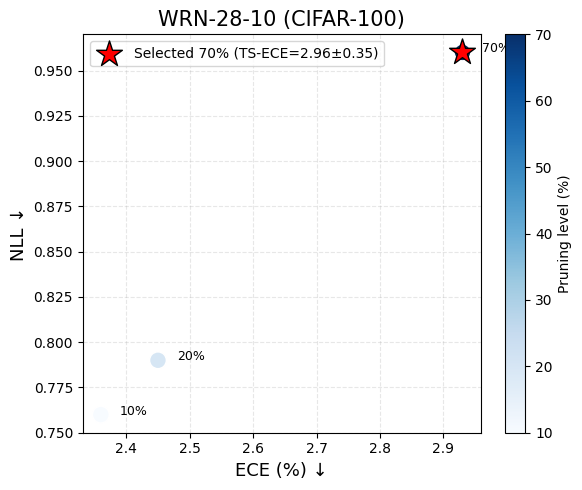

In [8]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Paths: CIFAR-100 selected-beta setting
# --------------------------------------------------

OURS_CSV = (
    "PRUNING/WRN28-10_CIFAR100/FOCAL_SBECE_PRUNE/"
    "HPO_beta/cifar100_selected_beta_raw_metrics_paper.csv"
)

OURS_TS_CSV = (
    "PRUNING/WRN28-10_CIFAR100/FOCAL_SBECE_PRUNE/"
    "HPO_beta/cifar100_selected_beta_temperature_scaled_metrics_paper.csv"
)

GD_CSV = (
    "Baseline_Gate_Decorator/WRN28-10_CIFAR100/"
    "cifar100_raw_metrics_baseline_GD.csv"
)

OUT_DIR = (
    "PRUNING/WRN28-10_CIFAR100/FOCAL_SBECE_PRUNE/"
    "HPO_beta"
)
os.makedirs(OUT_DIR, exist_ok=True)

OUT_SELECTED_CSV = os.path.join(
    OUT_DIR,
    "cifar100_pareto_selected_operating_point_with_ts_std.csv"
)

OUT_SELECTED_SUMMARY_CSV = os.path.join(
    OUT_DIR,
    "cifar100_pareto_selected_operating_point_summary_for_table.csv"
)

OUT_PARETO_CSV = os.path.join(
    OUT_DIR,
    "cifar100_pareto_front_points_with_ts_std.csv"
)

OUT_PLOT = os.path.join(
    OUT_DIR,
    "pareto_ece_nll_selected_beta_wrn_cifar100_with_ts_std.pdf"
)


# --------------------------------------------------
# Helpers
# --------------------------------------------------

def parse_mean_std(x):
    """
    Converts:
    '79.60 ± 0.42' -> (79.60, 0.42)
    '79.60\\pm0.42' -> (79.60, 0.42)
    '79.60' -> (79.60, np.nan)
    """
    x = str(x).strip()
    x = x.replace("%", "")
    x = x.replace("$", "")
    x = x.replace("\\pm", "±")
    x = x.replace("+/-", "±")

    if x in ["--", "nan", "NaN", "None", ""]:
        return np.nan, np.nan

    if "±" in x:
        mean, std = x.split("±", 1)
        return float(mean.strip()), float(std.strip())

    return float(x.strip()), np.nan


def parse_mean(x):
    return parse_mean_std(x)[0]


def parse_std(x):
    return parse_mean_std(x)[1]


def fmt_mean_std(mean, std, digits=2):
    if pd.isna(mean):
        return "--"
    if pd.isna(std):
        return f"{mean:.{digits}f}"
    return f"{mean:.{digits}f}±{std:.{digits}f}"


def add_pruning_percent(df):
    df = df.copy()

    if "pruning_%" in df.columns:
        df["pruning_%"] = df["pruning_%"].apply(parse_mean).round(0).astype(int)

    elif "prune (%)" in df.columns:
        df["pruning_%"] = df["prune (%)"].apply(parse_mean).round(0).astype(int)

    elif "Prune (%)" in df.columns:
        df["pruning_%"] = df["Prune (%)"].apply(parse_mean).round(0).astype(int)

    elif "prune_ratio" in df.columns:
        prune_vals = df["prune_ratio"].apply(parse_mean)
        if prune_vals.max() <= 1.0:
            df["pruning_%"] = (prune_vals * 100).round(0).astype(int)
        else:
            df["pruning_%"] = prune_vals.round(0).astype(int)

    else:
        raise KeyError(
            "Could not find pruning column. Available columns:\n"
            + str(df.columns.tolist())
        )

    return df


def load_ours_raw_metrics(csv_path):
    df = pd.read_csv(csv_path)
    df = add_pruning_percent(df)

    required = ["acc (%)", "nll", "ece (%)"]
    missing = [c for c in required if c not in df.columns]
    if len(missing) > 0:
        raise KeyError(
            f"Missing columns in OUR raw CSV: {missing}\n"
            f"Available columns: {df.columns.tolist()}"
        )

    df["acc_mean"] = df["acc (%)"].apply(parse_mean)
    df["acc_std"] = df["acc (%)"].apply(parse_std)

    df["nll_mean"] = df["nll"].apply(parse_mean)
    df["nll_std"] = df["nll"].apply(parse_std)

    df["ece_mean"] = df["ece (%)"].apply(parse_mean)
    df["ece_std"] = df["ece (%)"].apply(parse_std)

    if "beta" in df.columns:
        df["beta"] = df["beta"].astype(str)
    else:
        df["beta"] = "--"

    return df[[
        "pruning_%",
        "beta",
        "acc_mean", "acc_std",
        "nll_mean", "nll_std",
        "ece_mean", "ece_std",
    ]].copy()


def load_ours_ts_metrics(csv_path):
    df = pd.read_csv(csv_path)
    df = add_pruning_percent(df)

    required = ["raw_ece (%)", "raw_nll", "ts_ece (%)", "ts_nll", "temperature"]
    missing = [c for c in required if c not in df.columns]
    if len(missing) > 0:
        raise KeyError(
            f"Missing columns in OUR TS CSV: {missing}\n"
            f"Available columns: {df.columns.tolist()}"
        )

    df["raw_ece_mean_from_ts"] = df["raw_ece (%)"].apply(parse_mean)
    df["raw_ece_std_from_ts"] = df["raw_ece (%)"].apply(parse_std)

    df["raw_nll_mean_from_ts"] = df["raw_nll"].apply(parse_mean)
    df["raw_nll_std_from_ts"] = df["raw_nll"].apply(parse_std)

    df["ts_ece_mean"] = df["ts_ece (%)"].apply(parse_mean)
    df["ts_ece_std"] = df["ts_ece (%)"].apply(parse_std)

    df["ts_nll_mean"] = df["ts_nll"].apply(parse_mean)
    df["ts_nll_std"] = df["ts_nll"].apply(parse_std)

    df["temperature_mean"] = df["temperature"].apply(parse_mean)
    df["temperature_std"] = df["temperature"].apply(parse_std)

    keep_cols = [
        "pruning_%",
        "raw_ece_mean_from_ts", "raw_ece_std_from_ts",
        "raw_nll_mean_from_ts", "raw_nll_std_from_ts",
        "ts_ece_mean", "ts_ece_std",
        "ts_nll_mean", "ts_nll_std",
        "temperature_mean", "temperature_std",
    ]

    if "beta" in df.columns:
        df["beta_ts"] = df["beta"].astype(str)
        keep_cols.append("beta_ts")

    return df[keep_cols].copy()


def load_gd_raw_metrics(csv_path):
    df = pd.read_csv(csv_path)
    df = add_pruning_percent(df)

    required = ["acc (%)", "nll", "ece (%)"]
    missing = [c for c in required if c not in df.columns]
    if len(missing) > 0:
        raise KeyError(
            f"Missing columns in GD CSV: {missing}\n"
            f"Available columns: {df.columns.tolist()}"
        )

    df["acc_mean_gd"] = df["acc (%)"].apply(parse_mean)
    df["acc_std_gd"] = df["acc (%)"].apply(parse_std)

    df["nll_mean_gd"] = df["nll"].apply(parse_mean)
    df["nll_std_gd"] = df["nll"].apply(parse_std)

    df["ece_mean_gd"] = df["ece (%)"].apply(parse_mean)
    df["ece_std_gd"] = df["ece (%)"].apply(parse_std)

    return df[[
        "pruning_%",
        "acc_mean_gd", "acc_std_gd",
        "nll_mean_gd", "nll_std_gd",
        "ece_mean_gd", "ece_std_gd",
    ]].copy()


# --------------------------------------------------
# 1. Load OUR raw + TS selected-beta results
# --------------------------------------------------

df_ours_raw = load_ours_raw_metrics(OURS_CSV)
df_ours_ts = load_ours_ts_metrics(OURS_TS_CSV)

df_ours = df_ours_raw.merge(
    df_ours_ts,
    on="pruning_%",
    how="left"
)

print("OURS raw + TS:")
display(df_ours)


# --------------------------------------------------
# 2. Load GD baseline results
# --------------------------------------------------

df_gd = load_gd_raw_metrics(GD_CSV)

print("GD:")
display(df_gd)


# --------------------------------------------------
# 3. Merge ours + GD by pruning level
# --------------------------------------------------

df = df_ours.merge(
    df_gd,
    on="pruning_%",
    how="inner"
)

df = df.sort_values("pruning_%").reset_index(drop=True)

# exclude unpruned baseline from operating-point selection
df = df[df["pruning_%"] > 0].copy()

print("Merged Ours + GD:")
display(df)


# --------------------------------------------------
# 4. Accuracy constraint relative to GD
# Rule: Ours must be within 1 percentage point of GD
# --------------------------------------------------

ACC_TOL_PCT = 1.0

df["acc_floor"] = df["acc_mean_gd"] - ACC_TOL_PCT
df_feasible = df[df["acc_mean"] >= df["acc_floor"]].copy()

print("Feasible pruning levels:", df_feasible["pruning_%"].tolist())

if len(df_feasible) == 0:
    raise ValueError(
        "No feasible pruning levels found. "
        "Try increasing ACC_TOL_PCT or check metric scaling."
    )


# --------------------------------------------------
# 5. Compute improvements/differences vs GD
# Lower is better for dECE and dNLL
# --------------------------------------------------

df_feasible["dECE"] = df_feasible["ece_mean"] - df_feasible["ece_mean_gd"]
df_feasible["dNLL"] = df_feasible["nll_mean"] - df_feasible["nll_mean_gd"]

# Optional uncertainty for deltas, assuming independent bootstrap estimates
df_feasible["dECE_std"] = np.sqrt(
    df_feasible["ece_std"].fillna(0) ** 2 +
    df_feasible["ece_std_gd"].fillna(0) ** 2
)

df_feasible["dNLL_std"] = np.sqrt(
    df_feasible["nll_std"].fillna(0) ** 2 +
    df_feasible["nll_std_gd"].fillna(0) ** 2
)

print("Feasible with raw + TS metrics:")
display(df_feasible[[
    "pruning_%",
    "beta",
    "acc_mean", "acc_std",
    "acc_mean_gd", "acc_std_gd",
    "ece_mean", "ece_std",
    "ece_mean_gd", "ece_std_gd",
    "dECE", "dECE_std",
    "nll_mean", "nll_std",
    "nll_mean_gd", "nll_std_gd",
    "dNLL", "dNLL_std",
    "ts_ece_mean", "ts_ece_std",
    "ts_nll_mean", "ts_nll_std",
    "temperature_mean",
]])


# --------------------------------------------------
# 6. Pareto front on raw mean values: dECE and dNLL
# --------------------------------------------------

obj_cols = ["dECE", "dNLL"]

def is_dominated(i, data, cols):
    xi = data.loc[i, cols].to_numpy(dtype=float)

    for j in data.index:
        if j == i:
            continue

        xj = data.loc[j, cols].to_numpy(dtype=float)

        if np.all(xj <= xi) and np.any(xj < xi):
            return True

    return False


pareto_idx = [
    i for i in df_feasible.index
    if not is_dominated(i, df_feasible, obj_cols)
]

df_pareto = df_feasible.loc[pareto_idx].sort_values("pruning_%").copy()

print("\nPareto pruning levels:", df_pareto["pruning_%"].tolist())

df_pareto.to_csv(OUT_PARETO_CSV, index=False)
print("Saved Pareto front ->", OUT_PARETO_CSV)

display(df_pareto[[
    "pruning_%",
    "beta",
    "acc_mean", "acc_std",
    "ece_mean", "ece_std",
    "nll_mean", "nll_std",
    "dECE", "dECE_std",
    "dNLL", "dNLL_std",
    "ts_ece_mean", "ts_ece_std",
    "ts_nll_mean", "ts_nll_std",
    "temperature_mean",
]])


# --------------------------------------------------
# 7. Select one operating point
# Rule:
# 1. Best dECE
# 2. Then best dNLL
# 3. Then higher pruning
# --------------------------------------------------

df_selected = df_pareto.sort_values(
    ["dECE", "dNLL", "pruning_%"],
    ascending=[True, True, False]
).iloc[0].copy()

print("\nSelected operating point with TS metrics:")
display(pd.DataFrame([df_selected])[[
    "pruning_%",
    "beta",
    "acc_mean", "acc_std",
    "acc_mean_gd", "acc_std_gd",
    "ece_mean", "ece_std",
    "ece_mean_gd", "ece_std_gd",
    "dECE", "dECE_std",
    "nll_mean", "nll_std",
    "nll_mean_gd", "nll_std_gd",
    "dNLL", "dNLL_std",
    "ts_ece_mean", "ts_ece_std",
    "ts_nll_mean", "ts_nll_std",
    "temperature_mean",
]])


# --------------------------------------------------
# 8. Save selected operating point + table-ready summary
# --------------------------------------------------

pd.DataFrame([df_selected]).to_csv(OUT_SELECTED_CSV, index=False)
print("Saved selected operating point ->", OUT_SELECTED_CSV)

summary = pd.DataFrame([{
    "pruning_%": int(df_selected["pruning_%"]),
    "beta": df_selected["beta"],

    "ours_acc": fmt_mean_std(df_selected["acc_mean"], df_selected["acc_std"]),
    "gd_acc": fmt_mean_std(df_selected["acc_mean_gd"], df_selected["acc_std_gd"]),

    "ours_ece": fmt_mean_std(df_selected["ece_mean"], df_selected["ece_std"]),
    "gd_ece": fmt_mean_std(df_selected["ece_mean_gd"], df_selected["ece_std_gd"]),

    "ours_nll": fmt_mean_std(df_selected["nll_mean"], df_selected["nll_std"]),
    "gd_nll": fmt_mean_std(df_selected["nll_mean_gd"], df_selected["nll_std_gd"]),

    "ours_ts_ece": fmt_mean_std(df_selected["ts_ece_mean"], df_selected["ts_ece_std"]),
    "ours_ts_nll": fmt_mean_std(df_selected["ts_nll_mean"], df_selected["ts_nll_std"]),

    "temperature": fmt_mean_std(
        df_selected["temperature_mean"],
        df_selected.get("temperature_std", np.nan),
    ),

    "dECE": fmt_mean_std(df_selected["dECE"], df_selected["dECE_std"]),
    "dNLL": fmt_mean_std(df_selected["dNLL"], df_selected["dNLL_std"]),
}])

summary.to_csv(OUT_SELECTED_SUMMARY_CSV, index=False)
print("Saved table-ready selected summary ->", OUT_SELECTED_SUMMARY_CSV)

display(summary)


# --------------------------------------------------
# 9. Plot raw ECE vs raw NLL for feasible points
# Star includes TS-ECE mean ± std in label
# --------------------------------------------------

plot_df = df_feasible.sort_values("pruning_%").reset_index(drop=True)

plt.figure(figsize=(6, 5))

norm = plt.Normalize(plot_df["pruning_%"].min(), plot_df["pruning_%"].max())
cmap = plt.cm.Blues

sc = plt.scatter(
    plot_df["ece_mean"],
    plot_df["nll_mean"],
    c=plot_df["pruning_%"],
    cmap=cmap,
    norm=norm,
    s=150,
    edgecolor="white",
    linewidth=1.2
)

plt.scatter(
    df_selected["ece_mean"],
    df_selected["nll_mean"],
    marker="*",
    s=380,
    color="red",
    edgecolor="black",
    label=(
        f'Selected {int(df_selected["pruning_%"])}% '
        f'(TS-ECE={fmt_mean_std(df_selected["ts_ece_mean"], df_selected["ts_ece_std"])})'
    ),
    zorder=5
)

for _, r in plot_df.iterrows():
    plt.text(
        r["ece_mean"] + 0.03,
        r["nll_mean"],
        f'{int(r["pruning_%"])}%',
        fontsize=9
    )

cbar = plt.colorbar(sc)
cbar.set_label("Pruning level (%)")

plt.title("WRN-28-10 (CIFAR-100)", fontsize=15)
plt.xlabel("ECE (%) ↓", fontsize=13)
plt.ylabel("NLL ↓", fontsize=13)

plt.grid(True, linestyle="--", alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(OUT_PLOT, dpi=300, bbox_inches="tight")
print("Saved plot ->", OUT_PLOT)

plt.show()

[WARN] GD_FLOP_CSV not found. Reusing OURS_FLOP_CSV for GD.
Saved merged CSV -> PRUNING/WRN28-10_CIFAR100/FOCAL_SBECE_PRUNE/HPO_beta/ece_vs_effective_flops_ours_vs_gd_wrn_cifar100.csv


,pruning_%,ours_ece_mean,ours_ece_std,ours_flop_reduction_%,gd_ece_mean,gd_ece_std,gd_flop_reduction_%
0,0,6.26,0.33,0.000000,4.30,0.30,0.000000
1,10,2.36,0.31,19.000004,4.92,0.29,19.000004
2,20,2.45,0.28,35.999998,5.42,0.32,35.999998
3,30,2.03,0.29,51.000002,6.09,0.31,51.000002
4,40,1.66,0.30,63.999997,6.86,0.33,63.999997
5,50,1.96,0.32,75.000000,7.78,0.33,75.000000
6,60,2.18,0.32,84.000000,9.33,0.36,84.000000
7,70,2.93,0.35,90.999999,11.00,0.37,90.999999


Saved plot -> PRUNING/WRN28-10_CIFAR100/FOCAL_SBECE_PRUNE/HPO_beta/ece_vs_effective_flops_ours_vs_gd_wrn_cifar100.pdf


/tmp/ipykernel_11065/2499020092.py:304: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=False)


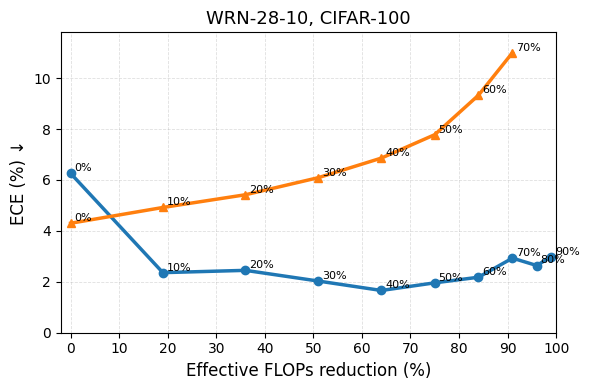

In [7]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Paths: CIFAR-100
# --------------------------------------------------

OURS_METRICS_CSV = (
    "PRUNING/WRN28-10_CIFAR100/FOCAL_SBECE_PRUNE/"
    "HPO_beta/cifar100_selected_beta_raw_metrics_paper.csv"
)

GD_METRICS_CSV = (
    "Baseline_Gate_Decorator/WRN28-10_CIFAR100/"
    "cifar100_raw_metrics_baseline_GD.csv"
)

OURS_FLOP_CSV = (
    "PRUNING/WRN28-10_CIFAR100/FOCAL_SBECE_PRUNE/"
    "results/wrn28_10_cifar100_effective_flops_layerwise.csv"
)

# Update this if you have a separate GD FLOP CSV.
# If not found, the code will reuse OURS_FLOP_CSV.
GD_FLOP_CSV = (
    "Baseline_Gate_Decorator/WRN28-10_CIFAR100/"
    "wrn28_10_cifar100_effective_flops_gd.csv"
)

OUT_DIR = (
    "PRUNING/WRN28-10_CIFAR100/FOCAL_SBECE_PRUNE/"
    "HPO_beta"
)
os.makedirs(OUT_DIR, exist_ok=True)

OUT_PLOT = os.path.join(
    OUT_DIR,
    "ece_vs_effective_flops_ours_vs_gd_wrn_cifar100.pdf"
)

OUT_MERGED_CSV = os.path.join(
    OUT_DIR,
    "ece_vs_effective_flops_ours_vs_gd_wrn_cifar100.csv"
)


# --------------------------------------------------
# Helpers
# --------------------------------------------------

def parse_mean_std(x):
    """
    Converts:
    '2.93 ± 0.35' -> (2.93, 0.35)
    '2.93'        -> (2.93, np.nan)
    """
    x = str(x).strip()
    x = x.replace("%", "")
    x = x.replace("$", "")
    x = x.replace("\\pm", "±")
    x = x.replace("+/-", "±")

    if x in ["--", "nan", "NaN", "None", ""]:
        return np.nan, np.nan

    if "±" in x:
        mean, std = x.split("±", 1)
        return float(mean.strip()), float(std.strip())

    return float(x.strip()), np.nan


def parse_mean(x):
    return parse_mean_std(x)[0]


def parse_std(x):
    return parse_mean_std(x)[1]


def add_pruning_percent(df):
    df = df.copy()

    if "pruning_%" in df.columns:
        df["pruning_%"] = df["pruning_%"].apply(parse_mean).round(0).astype(int)

    elif "prune (%)" in df.columns:
        df["pruning_%"] = df["prune (%)"].apply(parse_mean).round(0).astype(int)

    elif "Prune (%)" in df.columns:
        df["pruning_%"] = df["Prune (%)"].apply(parse_mean).round(0).astype(int)

    elif "prune_ratio" in df.columns:
        if df["prune_ratio"].max() <= 1.0:
            df["pruning_%"] = (df["prune_ratio"] * 100).round(0).astype(int)
        else:
            df["pruning_%"] = df["prune_ratio"].round(0).astype(int)

    else:
        raise KeyError(
            "Could not find pruning column. Available columns:\n"
            + str(df.columns.tolist())
        )

    return df


def find_ece_column(df):
    candidates = ["ece (%)", "ECE (%)", "ece", "ECE"]
    for c in candidates:
        if c in df.columns:
            return c

    matches = [
        c for c in df.columns
        if "ece" in c.lower() and "ts" not in c.lower()
    ]

    if len(matches) > 0:
        return matches[0]

    raise KeyError(
        "Could not find ECE column. Available columns:\n"
        + str(df.columns.tolist())
    )


def find_flop_reduction_column(df):
    candidates = [
        "effective_flop_reduction_%",
        "FLOP Reduction (%)",
        "FLOPs Red. (%)",
        "flop_reduction_%",
    ]

    for c in candidates:
        if c in df.columns:
            return c

    matches = [
        c for c in df.columns
        if "flop" in c.lower()
        and "reduct" in c.lower()
    ]

    if len(matches) > 0:
        return matches[0]

    return None


def load_metrics(metrics_csv, method_name):
    df = pd.read_csv(metrics_csv)
    df = add_pruning_percent(df)

    ece_col = find_ece_column(df)

    df[f"{method_name}_ece_mean"] = df[ece_col].apply(parse_mean)
    df[f"{method_name}_ece_std"] = df[ece_col].apply(parse_std)

    keep_cols = [
        "pruning_%",
        f"{method_name}_ece_mean",
        f"{method_name}_ece_std",
    ]

    flop_col = find_flop_reduction_column(df)
    if flop_col is not None:
        df[f"{method_name}_flop_reduction_%"] = df[flop_col].apply(parse_mean)
        keep_cols.append(f"{method_name}_flop_reduction_%")

    return df[keep_cols].copy()


def load_flops(flop_csv, method_name):
    df = pd.read_csv(flop_csv)
    df = add_pruning_percent(df)

    flop_col = find_flop_reduction_column(df)

    if flop_col is None:
        raise KeyError(
            f"Could not find FLOP reduction column in {flop_csv}.\n"
            f"Available columns: {df.columns.tolist()}"
        )

    df[f"{method_name}_flop_reduction_%"] = df[flop_col].apply(parse_mean)

    return df[[
        "pruning_%",
        f"{method_name}_flop_reduction_%",
    ]].copy()


def attach_flops(metrics_df, flop_csv, method_name):
    flop_col_name = f"{method_name}_flop_reduction_%"

    if flop_col_name in metrics_df.columns:
        return metrics_df

    if not os.path.exists(flop_csv):
        raise FileNotFoundError(
            f"FLOP CSV not found for {method_name}:\n{flop_csv}"
        )

    df_flop = load_flops(flop_csv, method_name)

    out = metrics_df.merge(
        df_flop,
        on="pruning_%",
        how="left"
    )

    return out


# --------------------------------------------------
# 1. Load Ours and GD metrics
# --------------------------------------------------

df_ours = load_metrics(OURS_METRICS_CSV, "ours")
df_gd = load_metrics(GD_METRICS_CSV, "gd")

df_ours = attach_flops(df_ours, OURS_FLOP_CSV, "ours")

if os.path.exists(GD_FLOP_CSV):
    df_gd = attach_flops(df_gd, GD_FLOP_CSV, "gd")
else:
    print("[WARN] GD_FLOP_CSV not found. Reusing OURS_FLOP_CSV for GD.")
    df_gd = attach_flops(df_gd, OURS_FLOP_CSV, "gd")


# --------------------------------------------------
# 2. Merge for inspection and save
# --------------------------------------------------

df_compare = df_ours.merge(
    df_gd,
    on="pruning_%",
    how="inner"
).sort_values("pruning_%").reset_index(drop=True)

df_compare.to_csv(OUT_MERGED_CSV, index=False)
print("Saved merged CSV ->", OUT_MERGED_CSV)

display(df_compare)


# --------------------------------------------------
# 3. Plot ECE vs Effective FLOP Reduction
# --------------------------------------------------

plt.figure(figsize=(6, 4))

plt.plot(
    df_ours["ours_flop_reduction_%"],
    df_ours["ours_ece_mean"],
    marker="o",
    linewidth=2.5,
    markersize=6,
   
)

plt.plot(
    df_gd["gd_flop_reduction_%"],
    df_gd["gd_ece_mean"],
    marker="^",
    linewidth=2.5,
    markersize=6,
   
)

# Annotate pruning %
for _, row in df_ours.iterrows():
    plt.text(
        row["ours_flop_reduction_%"] + 0.8,
        row["ours_ece_mean"] + 0.08,
        f"{int(row['pruning_%'])}%",
        fontsize=8,
    )

for _, row in df_gd.iterrows():
    plt.text(
        row["gd_flop_reduction_%"] + 0.8,
        row["gd_ece_mean"] + 0.08,
        f"{int(row['pruning_%'])}%",
        fontsize=8,
    )

plt.xlabel("Effective FLOPs reduction (%)", fontsize=12)
plt.ylabel("ECE (%) ↓", fontsize=12)
plt.title("WRN-28-10, CIFAR-100", fontsize=13)

plt.xlim(-2, 100)
plt.xticks(np.arange(0, 101, 10))

y_min = 0
y_max = max(df_ours["ours_ece_mean"].max(), df_gd["gd_ece_mean"].max()) + 0.8
plt.ylim(y_min, y_max)

plt.grid(True, linestyle="--", linewidth=0.6, alpha=0.4)
plt.legend(frameon=False)

plt.tight_layout()

plt.savefig(OUT_PLOT, dpi=300, bbox_inches="tight")
print("Saved plot ->", OUT_PLOT)

plt.show()